# Clusters com modelos não supervisionados: K-Means, hierárquico e DBSCAN (reutilizável)

**Objetivo:** achar, com três modelos não supervisionados, grupos de entidades (segmentos da carteira, clientes…) com comportamento parecido. Depois, comparar os modelos, dar nome a cada grupo e mostrar onde está o valor.

A modelagem (seção 8) sobe em três camadas, como no notebook Mall: **univariada** (1 feature), **bivariada** (2) e **multivariada** (todas), cada uma com seu gráfico de cotovelo/silhouette e sua tabela de perfil (média das features, nº de entidades e % do total — o formato do `profile_bi` do Mall).

**Para usar com outra tabela, só a célula `CONFIGURAÇÃO DA TABELA` muda.** O resto do notebook não tem nenhum nome de coluna escrito. A tabela pode ter uma linha por segmento e mês, como a `base_analitica_pesos`, ou já uma linha por entidade.

A lógica vem dos três notebooks de referência:

- **Mall:** checagem de qualidade, k pelo silhouette e nome de negócio para cada grupo.
- **Clusterização:** tabela com uma linha por entidade, escala, K-Means e DBSCAN (com gráfico de k-distância), clustering hierárquico (o próximo passo sugerido lá), PCA, perfil em desvios-padrão e regras × clusters.
- **RFM:** limpeza com relatório por motivo, log nas variáveis com cauda longa, nome pelo centróide e % da base × % do valor.

> A tabela de exemplo (`base_analitica_pesos_1.xlsx`) vem do `dados_demo.xlsx` e tem **dados inventados**. Os números só ilustram o método. Nada aqui mostra causa: são agrupamentos e associações.

## 1. Importação e preparação

### Configuração

Cada item diz ao notebook o papel de cada coluna:

| Item | O que é | Na carteira de recuperação |
|---|---|---|
| `ENTIDADE` | colunas que identificam o que vai ser agrupado (cada combinação vira um ponto nos modelos) | UF, Carteira, Faixa Aging |
| `COLUNA_DATA` | data ou mês de cada linha (`None` se não houver) | Mês |
| `NOVAS_COLUNAS` | colunas calculadas antes de tudo | — |
| `FILTROS` | condição para a linha **ficar**; o nome é o motivo da saída | saldo > 0; recuperado ≤ 100% do devedor |
| `SOMAR`, `MEDIA`, `CONTAR_DISTINTOS` | como juntar as várias linhas de cada entidade | saldos e ECS somados; pesos pela média dos meses |
| `TAXAS` | taxa = Σ numerador ÷ Σ denominador (nunca média de taxas) | Eficácia, Taxa ECS |
| `TAXA_PRINCIPAL` | a taxa que o notebook analisa | Eficácia |
| `REFERENCIA` | compara a taxa de cada entidade com a da sua categoria (`None` desliga) | Faixa Aging |
| `PESO` | coluna de valor para "% do valor" (`None` = só contagem) | Saldo Devedor |
| `FEATURES` | candidatas para os modelos, em ordem de prioridade (as redundantes saem sozinhas) | Peso Financeiro, Eficácia, Peso ECS, Taxa ECS |
| `LOG` | features com cauda longa (log antes de padronizar) | Peso Financeiro, Peso ECS |
| `CATEGORIAS` | categorias para perfis e cruzamentos (não entram nos modelos) | UF, Carteira, Faixa Aging |

Quando `COLUNA_DATA` existe, o notebook também cria `Recência (dias)` e `Nº de meses com dados`. Com uma `TAXA_PRINCIPAL`, cria ainda a tendência da taxa por mês. Qualquer uma dessas colunas pode entrar em `FEATURES`.

**Exemplos para as tabelas das referências** (é só colar no lugar da célula `CONFIGURAÇÃO DA TABELA`):

```python
# Tabela tipo Mall Customers (um cliente por linha)
CAMINHO = "Mall_Customers.csv"; ABA = 0
ENTIDADE = ["CustomerID"]; COLUNA_DATA = None; NOVAS_COLUNAS = {}; FILTROS = {}
SOMAR = []; MEDIA = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]; CONTAR_DISTINTOS = {}
TAXAS = {}; TAXA_PRINCIPAL = None; REFERENCIA = None; PESO = None
FEATURES = ["Annual Income (k$)", "Spending Score (1-100)"]; LOG = []; CATEGORIAS = ["Gender"]

# Tabela tipo Online Retail (transações -> RFM por cliente)
CAMINHO = "online_retail_II.xlsx"; ABA = 0
ENTIDADE = ["Customer ID"]; COLUNA_DATA = "InvoiceDate"; NOVAS_COLUNAS = {"Valor": "Quantity * Price"}
FILTROS = {"fatura de cancelamento": "~Invoice.astype('str').str.startswith('C')",
           "quantidade ≤ 0": "Quantity > 0", "preço ≤ 0": "Price > 0"}
SOMAR = ["Valor"]; MEDIA = []; CONTAR_DISTINTOS = {"Frequência": "Invoice"}
TAXAS = {}; TAXA_PRINCIPAL = None; REFERENCIA = None; PESO = "Valor"
FEATURES = ["Recência (dias)", "Frequência", "Valor"]; LOG = ["Frequência", "Valor"]; CATEGORIAS = ["Country"]
```

A segunda célula, `CONFIGURAÇÃO DOS MODELOS`, não depende da tabela. Nela você escolhe o modelo usado na interpretação e o k, e pode fixar os parâmetros do DBSCAN.

Logo depois das duas células, o notebook confere se a configuração faz sentido e, se não fizer, para com uma mensagem clara. Um exemplo é uma taxa cujo numerador não está em `SOMAR`.

In [1]:
# >>> CONFIGURAÇÃO DA TABELA: a única célula que muda de uma tabela para outra <<<
CAMINHO = "base_analitica_pesos_1.xlsx"   # .xlsx ou .csv
ABA = 0                                 # aba do Excel (ignorada em .csv)

ENTIDADE = ["UF", "Carteira", "Faixa Aging"]
COLUNA_DATA = "Mês"
NOVAS_COLUNAS = {}
FILTROS = {"Saldo Devedor ≤ 0": "`Saldo Devedor` > 0",
           "recuperado acima de 100% do devedor (provável erro)": "`Saldo Recuperado` <= 1.0 * `Saldo Devedor`"}
SOMAR = ["Saldo Devedor", "Saldo Recuperado", "ECS Carteira", "ECS Recuperação"]
MEDIA = ["Peso Financeiro", "Peso ECS"]
CONTAR_DISTINTOS = {}
TAXAS = {"Eficácia": ("Saldo Recuperado", "Saldo Devedor"), "Taxa ECS": ("ECS Recuperação", "ECS Carteira")}
TAXA_PRINCIPAL = "Eficácia"
REFERENCIA = "Faixa Aging"
PESO = "Saldo Devedor"
FEATURES = ["Peso Financeiro", "Eficácia", "Peso ECS", "Taxa ECS"]
LOG = ["Peso Financeiro", "Peso ECS"]
CATEGORIAS = ["UF", "Carteira", "Faixa Aging"]

In [2]:
# >>> CONFIGURAÇÃO DOS MODELOS (vale para qualquer tabela) <<<
MODELO_FINAL = "K-Means"               # modelo usado na interpretação: "K-Means", "Hierárquico" ou "DBSCAN"
K_MINIMO, K_FIXO = 3, None             # k = maior silhouette com k ≥ K_MINIMO; ou fixe um número em K_FIXO
DBSCAN_EPS, DBSCAN_MIN_AMOSTRAS = None, None   # None = automático (gráfico de k-distância e 2 × nº de features)
LIMIAR_REDUNDANCIA = 0.95              # |Spearman| a partir do qual uma feature sai por repetir outra
RANDOM_STATE = 42

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy import stats
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110

assert ENTIDADE and FEATURES, "ENTIDADE e FEATURES não podem ficar vazios."
assert MODELO_FINAL in ("K-Means", "Hierárquico", "DBSCAN"), 'MODELO_FINAL precisa ser "K-Means", "Hierárquico" ou "DBSCAN".'
assert TAXA_PRINCIPAL is None or TAXA_PRINCIPAL in TAXAS, "TAXA_PRINCIPAL precisa ser uma das chaves de TAXAS, ou None."
fora_de_somar = [c for par in TAXAS.values() for c in par if c not in SOMAR] + ([PESO] if PESO and PESO not in SOMAR else [])
assert not fora_de_somar, f"Taxas e PESO saem de somas; coloque em SOMAR: {fora_de_somar}"
LOG = [c for c in LOG if c in FEATURES]                  # LOG só vale para quem está em FEATURES
assert REFERENCIA is None or (TAXA_PRINCIPAL and REFERENCIA in ENTIDADE + CATEGORIAS), \
    "REFERENCIA precisa de uma TAXA_PRINCIPAL e tem que estar em ENTIDADE ou CATEGORIAS."

### Leitura e checagem de qualidade

Como no Mall: linhas, tipos e nulos das colunas que a configuração usa. As colunas que não são citadas na configuração são ignoradas.

In [4]:
df = pd.read_csv(CAMINHO) if str(CAMINHO).lower().endswith(".csv") else pd.read_excel(CAMINHO, sheet_name=ABA)
citadas = ENTIDADE + [COLUNA_DATA] * bool(COLUNA_DATA) + SOMAR + MEDIA + list(CONTAR_DISTINTOS.values()) + CATEGORIAS
citadas += [c for c in df.columns if any(c in expr for expr in list(NOVAS_COLUNAS.values()) + list(FILTROS.values()))]
citadas = [c for c in dict.fromkeys(citadas) if c not in NOVAS_COLUNAS]
faltando = [c for c in citadas if c not in df.columns]
assert not faltando, f"Colunas da configuração que não existem na tabela: {faltando}"
print(f"Linhas: {len(df)} | colunas usadas: {len(citadas)} de {df.shape[1]}")
pd.DataFrame({"tipo": df[citadas].dtypes.astype(str), "nulos": df[citadas].isna().sum(),
              "% nulos": (df[citadas].isna().mean() * 100).round(2)})

Linhas: 4256 | colunas usadas: 10 de 13


,tipo,nulos,% nulos
UF,object,0,0.00
Carteira,object,0,0.00
Faixa Aging,object,0,0.00
Mês,object,0,0.00
Saldo Devedor,float64,6,0.14
Saldo Recuperado,float64,6,0.14
ECS Carteira,float64,6,0.14
ECS Recuperação,float64,6,0.14
Peso Financeiro,float64,6,0.14
Peso ECS,float64,6,0.14


## 2. Tratamento e transformação

### Funções de apoio

- Leitura de números em texto brasileiro (`1.234,56`, `12,3%`).
- Leitura de mês em texto (`jan/26`) ou data.
- Formatadores de tabela: percentual com vírgula e p.p.

In [5]:
MESES = ["jan", "fev", "mar", "abr", "mai", "jun", "jul", "ago", "set", "out", "nov", "dez"]

def para_numero(s):
    """Texto como '1.234,56' ou '12,3%' vira número. O que já é número fica como está."""
    if pd.api.types.is_numeric_dtype(s): return s.astype("float64")
    ja_numero = s.map(lambda x: isinstance(x, (int, float, np.number)) and not isinstance(x, (bool, np.bool_)))
    t = s.where(~ja_numero).astype("string").str.replace("R$", "", regex=False).str.strip()
    em_pct = t.str.contains("%", regex=False).fillna(False)
    v = pd.to_numeric(t.str.replace("%", "", regex=False).str.replace(".", "", regex=False).str.replace(",", ".", regex=False), errors="coerce")
    return v.where(~em_pct, v / 100).where(~ja_numero, pd.to_numeric(s.where(ja_numero), errors="coerce")).astype("float64")

def para_data(s):
    """'jan/26' ou 'janeiro-2026' vira o 1º dia do mês; o resto vai para pd.to_datetime."""
    texto = s.astype("string").str.strip().str.lower()
    e_mes = texto.str.match(r"^(" + "|".join(MESES) + r")[a-zç]*[\s/\-.]*\d{2,4}$").fillna(False)
    iso = texto.str.match(r"^\d{4}[-/]").fillna(False)                   # aaaa-mm-dd (e datas do Excel): ano primeiro
    outras = pd.to_datetime(s.where(~e_mes & iso), errors="coerce", format="mixed")
    outras = outras.fillna(pd.to_datetime(s.where(~e_mes & ~iso), errors="coerce", dayfirst=True, format="mixed"))   # dd/mm/aaaa
    if not e_mes.any(): return outras
    ano = texto[e_mes].str.extract(r"(\d{2,4})$")[0].astype(int)
    mes = texto[e_mes].str[:3].map({m: i + 1 for i, m in enumerate(MESES)}).astype(int)
    de_mes = pd.to_datetime(pd.DataFrame({"year": ano.where(ano >= 100, ano + 2000), "month": mes, "day": 1}))
    return outras.where(~e_mes, de_mes.reindex(s.index))

In [6]:
def br_pct(x, casas=None):
    """12,3%; valores pequenos (como pesos de 0,19%) ganham mais casas."""
    if pd.isna(x): return "–"
    if casas is None: casas = 1 if abs(x) >= 0.01 or x == 0 else (2 if abs(x) >= 0.001 else 3)
    return f"{x * 100:.{casas}f}%".replace(".", ",")
br_pp = lambda x, casas=2: "–" if pd.isna(x) else f"{x:+.{casas}f}".replace(".", ",") + " p.p."
br_dec = lambda x, casas=2: "–" if pd.isna(x) else f"{x:.{casas}f}".replace(".", ",")
br_num = lambda x, casas=0: "–" if pd.isna(x) else f"{x:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")
e_fracao = lambda s: pd.api.types.is_float_dtype(s) and "p.p." not in str(s.name) and s.dropna().between(-1.5, 1.5).all()

def formata(t, casas_pct=1):
    """Tabela com % e p.p. no formato brasileiro."""
    f = {}
    for c in t.columns:
        n = str(c)
        if "p.p." in n: f[c] = br_pp
        elif n.startswith("%") or ((n in TAXAS or n.endswith(" esperada")) and e_fracao(t[c])): f[c] = lambda x: br_pct(x, casas_pct)
        elif n.startswith("média ") and n[6:] in globals().get("ent", {}) and e_fracao(ent[n[6:]]): f[c] = br_pct   # ex.: pesos
        elif pd.api.types.is_float_dtype(t[c]): f[c] = (lambda x: br_num(x, 2)) if t[c].abs().max() < 100 else br_num
    return t.style.format(f)

def eixo(ax, s, qual="x"):
    """Eixo em % para frações e em milhões para valores grandes."""
    a = ax.xaxis if qual == "x" else ax.yaxis
    if e_fracao(s) and a.get_scale() == "log": a.set_major_formatter(plt.FuncFormatter(lambda v, _: br_pct(v, 0 if v >= 0.01 else None)))
    elif e_fracao(s):
        casas = 0 if s.abs().max() >= 0.1 else (1 if s.abs().max() >= 0.01 else 2)       # casas pelo tamanho do eixo
        a.set_major_formatter(plt.FuncFormatter(lambda v, _: br_pct(v, casas)))
    elif s.abs().max() >= 1e6: a.set_major_formatter(plt.FuncFormatter(lambda v, _: br_num(v / 1e6) + " mi"))

### Limpeza com relatório por motivo

Do RFM: a tabela mostra **por que** cada linha saiu, e não só quantas. Cada linha conta no primeiro motivo que se aplica, na ordem da tabela:

1. linha idêntica a outra;
2. identificação, data ou valor numérico vazio (ou texto que não vira número ou data);
3. os `FILTROS` da configuração.

In [7]:
d = df.copy()
for c in dict.fromkeys(SOMAR + MEDIA + [c for c in citadas if any(c in e for e in NOVAS_COLUNAS.values())]):
    if c in d: d[c] = para_numero(d[c])                                  # colunas de valor viram número
for nome, expr in NOVAS_COLUNAS.items():
    d[nome] = d.eval(expr, engine="python")
if COLUNA_DATA: d["_data"] = para_data(d[COLUNA_DATA])

motivos = {"linha idêntica a outra": df.duplicated(),
           "identificação vazia (ENTIDADE)": d[ENTIDADE].isna().any(axis=1),
           "data vazia ou inválida": d["_data"].isna() if COLUNA_DATA else pd.Series(False, index=d.index),
           "valor numérico vazio ou inválido": d[SOMAR + MEDIA].isna().any(axis=1)}
for motivo, condicao in FILTROS.items():
    motivos[motivo] = ~d.eval(condicao, engine="python").fillna(False).astype(bool)
sai, relatorio = pd.Series(False, index=d.index), {}
for motivo, mascara in motivos.items():
    relatorio[motivo] = int((mascara & ~sai).sum()); sai |= mascara
relatorio["TOTAL MANTIDO"], relatorio["TOTAL REMOVIDO"] = int((~sai).sum()), int(sai.sum())
d = d[~sai].copy()
relatorio_limpeza = pd.DataFrame({"linhas": relatorio})
relatorio_limpeza["% do original"] = (relatorio_limpeza["linhas"] / len(df) * 100).round(2)
relatorio_limpeza

,linhas,% do original
linha idêntica a outra,0,0.00
identificação vazia (ENTIDADE),0,0.00
data vazia ou inválida,0,0.00
valor numérico vazio ou inválido,6,0.14
Saldo Devedor ≤ 0,0,0.00
recuperado acima de 100% do devedor (provável erro),0,0.00
TOTAL MANTIDO,4250,99.86
TOTAL REMOVIDO,6,0.14


## 3. Construção das tabelas

### Tabela por entidade (uma linha por entidade)

É a `features` do notebook de clusterização e a `rfm` do RFM: as várias linhas de cada entidade (meses, transações) viram uma só, somando, tirando a média ou contando, como diz a configuração. Quando a tabela já tem uma linha por entidade (como a Mall), nada muda.

In [8]:
def inclinacao(x, y):
    ok = np.isfinite(x) & np.isfinite(y)
    return np.polyfit(x[ok], y[ok], 1)[0] if ok.sum() >= 3 and np.ptp(x[ok]) > 0 else np.nan

def ordem_natural(s):
    # ordem pelo 1º número quando todos os valores têm número (ex.: faixas "0–30 dias"); senão, alfabética
    v = pd.unique(s.dropna().astype(str))
    v = sorted(v, key=lambda x: int(re.search(r"\d+", x).group())) if all(re.search(r"\d", x) for x in v) else sorted(v)
    return pd.Categorical(s.where(s.isna(), s.astype(str)), categories=v, ordered=True)

if COLUNA_DATA: d["_mes"] = d["_data"].dt.year * 12 + d["_data"].dt.month
g = d.groupby(ENTIDADE, observed=True)
partes = [g[SOMAR].sum()] if SOMAR else []
if MEDIA: partes.append(g[MEDIA].mean())
if CONTAR_DISTINTOS: partes.append(g.agg(**{nome: (col, "nunique") for nome, col in CONTAR_DISTINTOS.items()}))
extras = [c for c in CATEGORIAS if c not in ENTIDADE]
if extras: partes.append(g[extras].first())
if COLUNA_DATA:
    partes += [g["_mes"].nunique().rename("Nº de meses com dados"), (d["_data"].max() - g["_data"].max()).dt.days.rename("Recência (dias)")]
COL_TENDENCIA = f"Tendência {TAXA_PRINCIPAL} (p.p./mês)" if COLUNA_DATA and TAXA_PRINCIPAL else None
if COL_TENDENCIA:
    num, den = TAXAS[TAXA_PRINCIPAL]
    pm = d.groupby(ENTIDADE + ["_mes"], observed=True)[[num, den]].sum().reset_index()
    pm["_taxa"] = pm[num] / pm[den].where(pm[den] != 0)
    partes.append((pm.groupby(ENTIDADE, observed=True).apply(lambda b: inclinacao(b["_mes"].to_numpy(float), b["_taxa"].to_numpy(float)),
                                                             include_groups=False) * 100).rename(COL_TENDENCIA))
ent = pd.concat(partes, axis=1).reset_index()
for c in dict.fromkeys(ENTIDADE + CATEGORIAS):
    if not pd.api.types.is_numeric_dtype(ent[c]): ent[c] = ordem_natural(ent[c])

In [9]:
for nome, (num, den) in TAXAS.items():
    ent[nome] = ent[num] / ent[den].where(ent[den] != 0)

TAXA_GLOBAL = None
if TAXA_PRINCIPAL:
    num, den = TAXAS[TAXA_PRINCIPAL]
    TAXA_GLOBAL = ent[num].sum() / ent[den].sum()
if REFERENCIA:
    ref = ent.groupby(REFERENCIA, observed=True)[[num, den]].sum()
    TAXA_REF = ref[num] / ref[den]
    ent["_esperado"] = ent[den] * ent[REFERENCIA].map(TAXA_REF).astype(float)
    print(f"{TAXA_PRINCIPAL} de referência por {REFERENCIA}: " + " | ".join(f"{k}: {br_pct(v)}" for k, v in TAXA_REF.items()))
print(f"{len(ent)} entidades" + (f" | {TAXA_PRINCIPAL} global (Σ ÷ Σ): {br_pct(TAXA_GLOBAL, 2)}" if TAXA_PRINCIPAL else ""))
ent.head()

Eficácia de referência por Faixa Aging: 0–30 dias: 33,6% | 31–60 dias: 30,2% | 61–90 dias: 23,2% | 91–180 dias: 13,2% | 181–360 dias: 7,9% | 361–720 dias: 4,4% | 721+ dias: 2,4%
532 entidades | Eficácia global (Σ ÷ Σ): 9,79%


,UF,Carteira,Faixa Aging,Saldo Devedor,Saldo Recuperado,ECS Carteira,ECS Recuperação,Peso Financeiro,Peso ECS,Nº de meses com dados,Recência (dias),Tendência Eficácia (p.p./mês),Eficácia,Taxa ECS,_esperado
0,AC,Carteira A,0–30 dias,3287267.41,1122865.44,2256.0,1265.0,0.000107,0.000163,8,0,0.306408,0.341580,0.560727,1.103753e+06
1,AC,Carteira A,181–360 dias,11668209.93,946705.92,5767.0,745.0,0.000379,0.000416,8,0,-0.068097,0.081135,0.129183,9.271491e+05
2,AC,Carteira A,31–60 dias,3154375.01,909678.06,2102.0,968.0,0.000103,0.000152,8,0,0.326850,0.288386,0.460514,9.534673e+05
3,AC,Carteira A,361–720 dias,14315058.89,598776.22,6687.0,444.0,0.000465,0.000483,8,0,-0.039520,0.041828,0.066397,6.264720e+05
4,AC,Carteira A,61–90 dias,4130372.53,955760.64,2540.0,957.0,0.000134,0.000183,8,0,0.055513,0.231398,0.376772,9.581117e+05


A **taxa de referência** serve para separar desempenho de mix. Cada entidade é comparada com a taxa da sua própria categoria de `REFERENCIA`. Na carteira, por exemplo, dívida antiga recupera menos que dívida nova. Um grupo cheio de dívida antiga vai ter eficácia baixa mesmo que cobre tão bem quanto os outros.

### De onde vem cada coluna

A tabela abaixo é gerada a partir da configuração, e nada nela é inventado.

In [10]:
origem = {c: f"soma de {c}" for c in SOMAR} | {c: f"média de {c}" for c in MEDIA}
origem |= {n: f"nº de valores distintos de {c}" for n, c in CONTAR_DISTINTOS.items()}
origem |= {c: f"{c} (primeiro valor da entidade)" for c in extras}
origem |= {n: f"Σ {a} ÷ Σ {b}" for n, (a, b) in TAXAS.items()}
if COLUNA_DATA:
    origem |= {"Nº de meses com dados": f"meses distintos em {COLUNA_DATA}",
               "Recência (dias)": f"dias entre a última data da entidade e a última data da tabela ({COLUNA_DATA})"}
if COL_TENDENCIA:
    origem[COL_TENDENCIA] = f"inclinação da {TAXA_PRINCIPAL} mês a mês (reta de mínimos quadrados); precisa de 3 meses ou mais"
for nome, expr in NOVAS_COLUNAS.items():
    if nome in origem: origem[nome] += f", com {nome} = {expr}"
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame({"como é calculada": origem, "candidata aos modelos": {c: "sim" if c in FEATURES else "" for c in origem}}))

,como é calculada,candidata aos modelos
Saldo Devedor,soma de Saldo Devedor,
Saldo Recuperado,soma de Saldo Recuperado,
ECS Carteira,soma de ECS Carteira,
ECS Recuperação,soma de ECS Recuperação,
Peso Financeiro,média de Peso Financeiro,sim
Peso ECS,média de Peso ECS,sim
Eficácia,Σ Saldo Recuperado ÷ Σ Saldo Devedor,sim
Taxa ECS,Σ ECS Recuperação ÷ Σ ECS Carteira,sim
Nº de meses com dados,meses distintos em Mês,
Recência (dias),dias entre a última data da entidade e a última data da tabela (Mês),


### Log, redundância e artefato

Três cuidados antes dos modelos, que medem distância:

- **Log (RFM):** valores com cauda longa (poucas entidades enormes) puxam os grupos. As colunas em `LOG` entram em log: `log(x)` quando todos os valores são positivos, como os pesos, que são frações pequenas; senão, `log(1 + x)`. A tabela mostra o skew antes e depois; acima de 1 em módulo já é bem assimétrico.
- **Redundância:** duas features com correlação de Spearman ≥ `LIMIAR_REDUNDANCIA` medem quase a mesma coisa, e juntas pesariam em dobro. O notebook percorre `FEATURES` em ordem e tira dos modelos a que repete uma já mantida. Ela continua na tabela e nos perfis.
- **Artefato (Mall):** uma coluna de identificação numérica correlacionada com uma feature, como o `CustomerID` com a renda no Mall, indica que a tabela veio ordenada. Não é uma relação de negócio.

In [11]:
NOME_MODELO = {f"log {c}" if c in LOG else c: c for c in FEATURES}      # coluna no modelo -> feature original
for c in LOG:
    v = ent[c].dropna()
    assert (v >= 0).all(), f"{c} tem valores negativos e não pode ir para LOG (ou filtre em FILTROS)."
    ent[f"log {c}"] = np.log(ent[c]) if (v > 0).all() else np.log1p(ent[c])
display(pd.DataFrame({"skew original": [stats.skew(ent[c].dropna()) for c in FEATURES],
                      "skew como entra no modelo": [stats.skew(ent[c].dropna()) for c in NOME_MODELO]}, index=FEATURES).round(2))

rho = ent[list(NOME_MODELO)].corr("spearman")
COLS_MODELO = []
for c in NOME_MODELO:
    par = next((m for m in COLS_MODELO if abs(rho.loc[c, m]) >= LIMIAR_REDUNDANCIA), None)
    if par is None: COLS_MODELO.append(c)
    else: print(f"Fora dos modelos: {NOME_MODELO[c]} repete {NOME_MODELO[par]} (Spearman = {br_dec(rho.loc[c, par])}).")
FEATURES_MODELO = [NOME_MODELO[c] for c in COLS_MODELO]
ids_num = [c for c in ENTIDADE if pd.api.types.is_numeric_dtype(ent[c])]
for c in ids_num:
    for f in COLS_MODELO:
        r = ent[c].corr(ent[f], method="spearman")
        if abs(r) >= 0.5: print(f"[ALERTA] {c} (identificação) tem Spearman = {br_dec(r)} com {f}: provável ordenação da tabela.")
print("Entram nos modelos:", ", ".join(FEATURES_MODELO))

ent_m = ent.dropna(subset=COLS_MODELO).reset_index(drop=True)
print(f"Entidades nos modelos: {len(ent_m)} de {len(ent)} (as demais têm alguma feature vazia)")

,skew original,skew como entra no modelo
Peso Financeiro,4.70,-0.04
Eficácia,0.38,0.38
Peso ECS,4.41,0.01
Taxa ECS,0.38,0.38


Fora dos modelos: Peso ECS repete Peso Financeiro (Spearman = 0,96).
Fora dos modelos: Taxa ECS repete Eficácia (Spearman = 1,00).
Entram nos modelos: Peso Financeiro, Eficácia
Entidades nos modelos: 532 de 532 (as demais têm alguma feature vazia)


## 4. Métricas e indicadores

### Indicadores gerais

Os números de referência para o resto do notebook. As taxas são sempre Σ numerador ÷ Σ denominador.

**Concentração:** A pergunta central do RFM, "% dos clientes × % da receita", feita para a tabela inteira. Com as entidades em ordem da maior para a menor em `PESO`, a tabela mostra quanto do valor fica nas primeiras 5%, 10%, 20% e 50%.

In [12]:
kpis = {"linhas usadas": br_num(len(d)), "entidades": br_num(len(ent)), "entidades no modelo": br_num(len(ent_m))}
if COLUNA_DATA:
    kpis["período"] = f"{d['_data'].min():%d/%m/%Y} a {d['_data'].max():%d/%m/%Y}"
kpis |= {f"total de {c}": br_num(ent[c].sum()) for c in SOMAR}
kpis |= {f"{n} global": br_pct(ent[a].sum() / ent[b].sum(), 2) if e_fracao(ent[n]) else br_num(ent[a].sum() / ent[b].sum(), 2)
         for n, (a, b) in TAXAS.items()}
pd.Series(kpis).to_frame("valor")

,valor
linhas usadas,4.250
entidades,532
entidades no modelo,532
período,01/01/2026 a 01/08/2026
total de Saldo Devedor,30.797.174.021
total de Saldo Recuperado,3.016.157.888
total de ECS Carteira,13.851.862
total de ECS Recuperação,2.589.840
Eficácia global,"9,79%"
Taxa ECS global,"18,70%"


In [13]:
if PESO:
    ordem = ent.sort_values(PESO, ascending=False)
    acum = ordem[PESO].cumsum() / ordem[PESO].sum()
    concentracao = pd.DataFrame({"nº de entidades": [int(np.ceil(p * len(ordem))) for p in [0.05, 0.10, 0.20, 0.50]]},
                                index=[f"{int(p * 100)}% maiores" for p in [0.05, 0.10, 0.20, 0.50]])
    concentracao[f"% de {PESO}"] = [acum.iloc[n - 1] for n in concentracao["nº de entidades"]]
    if TAXA_PRINCIPAL:
        num = TAXAS[TAXA_PRINCIPAL][0]
        concentracao[f"% de {num}"] = [ordem[num].iloc[:n].sum() / ordem[num].sum() for n in concentracao["nº de entidades"]]
    display(formata(concentracao))
else:
    print("Sem PESO na configuração: a concentração não se aplica.")

,nº de entidades,% de Saldo Devedor,% de Saldo Recuperado
5% maiores,27,"34,6%","16,7%"
10% maiores,54,"50,1%","33,5%"
20% maiores,107,"67,7%","49,7%"
50% maiores,266,"91,1%","82,9%"


## 5. EDA

### Distribuição das features e das taxas

Como no Mall e no RFM: um histograma por variável, com o skew no título. Cada ponto é uma entidade.

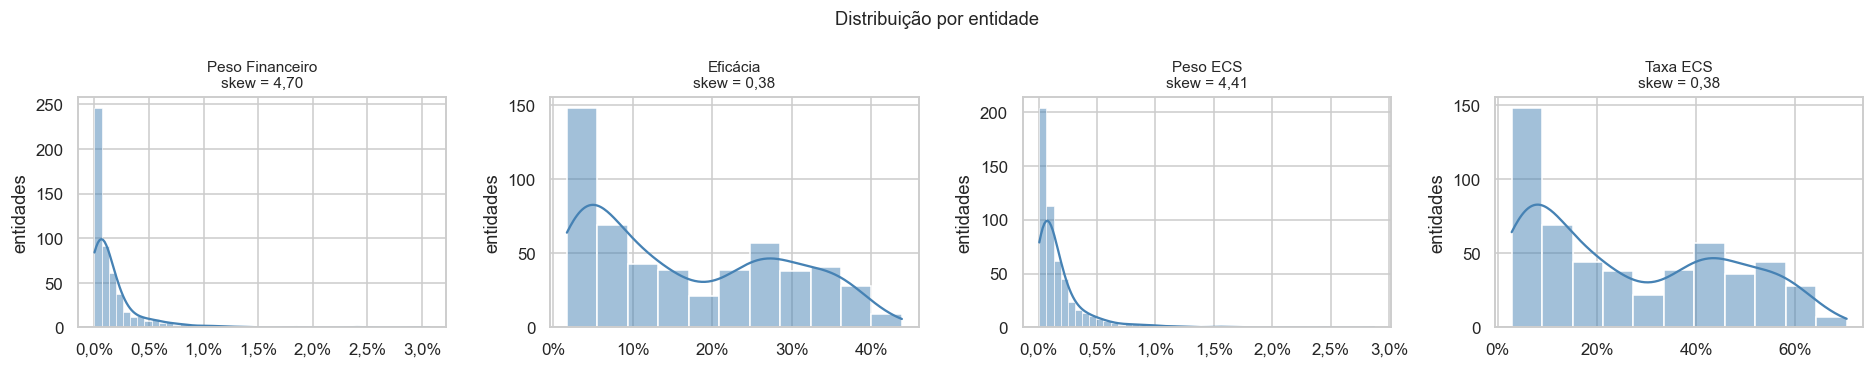

In [14]:
eda_cols = list(dict.fromkeys(FEATURES + list(TAXAS)))
ncol = min(4, len(eda_cols)); nlin = int(np.ceil(len(eda_cols) / ncol))
fig, axes = plt.subplots(nlin, ncol, figsize=(4.3 * ncol, 3.4 * nlin), squeeze=False)
for ax, c in zip(axes.flat, eda_cols):
    v = ent[c].dropna()
    sns.histplot(v, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"{c}\nskew = {br_dec(stats.skew(v))}", fontsize=10); ax.set_xlabel(""); ax.set_ylabel("entidades")
    eixo(ax, v)
for ax in axes.flat[len(eda_cols):]: ax.set_visible(False)
fig.suptitle("Distribuição por entidade", fontsize=12)
plt.tight_layout(); plt.show()

## 6. Segmentações e comparações

### Função de perfil

Uma função monta o perfil de qualquer segmentação, com o que as três referências mostram:

- **tamanho:** nº e % de entidades;
- **% do valor** (`PESO`), a coluna que prioriza orçamento no RFM;
- **as taxas**, ponderadas (Σ ÷ Σ);
- **Δ contra a taxa global** e **Δ contra a taxa esperada pela referência**: quando o primeiro é grande e o segundo fica perto de zero, a diferença vem do mix, não do desempenho;
- **a média de cada feature.**

Logo abaixo vem o perfil **por categoria**: é o `groupby("Gender")` do Mall, feito para cada coluna de `CATEGORIAS`.

In [15]:
def perfil(base, col, total=None, feats=None):
    ref_base = base if total is None else total
    g = base.groupby(col, observed=True)
    t = pd.DataFrame({"entidades": g.size()})
    t["% entidades"] = t["entidades"] / len(ref_base)
    if PESO: t[f"% {PESO}"] = g[PESO].sum() / ref_base[PESO].sum()
    for nome, (a, b) in TAXAS.items():
        t[nome] = g[a].sum() / g[b].sum()
    if TAXA_PRINCIPAL:
        a, b = TAXAS[TAXA_PRINCIPAL]
        t[f"Δ {TAXA_PRINCIPAL} vs global (p.p.)"] = (t[TAXA_PRINCIPAL] - TAXA_GLOBAL) * 100
        if REFERENCIA:
            t[f"Δ {TAXA_PRINCIPAL} vs esperada por {REFERENCIA} (p.p.)"] = (g[a].sum() - g["_esperado"].sum()) / g[b].sum() * 100
    for c in feats if feats is not None else FEATURES:
        if c not in TAXAS: t[f"média {c}"] = g[c].mean()
    return t

In [16]:
for c in CATEGORIAS:
    display(Markdown(f"**{c}**"))
    display(formata(perfil(ent, c)))

**UF**

,entidades,% entidades,% Saldo Devedor,Eficácia,Taxa ECS,Δ Eficácia vs global (p.p.),Δ Eficácia vs esperada por Faixa Aging (p.p.),média Peso Financeiro,média Peso ECS
UF,,,,,,,,,
AC,20,"3,8%","0,4%","9,0%","17,2%","-0,80 p.p.","-0,78 p.p.","0,021%","0,021%"
AL,20,"3,8%","1,4%","10,0%","18,9%","+0,21 p.p.","-0,21 p.p.","0,071%","0,073%"
AM,19,"3,6%","1,9%","8,0%","15,7%","-1,76 p.p.","-1,17 p.p.","0,098%","0,098%"
AP,19,"3,6%","0,4%","8,4%","16,2%","-1,38 p.p.","-0,45 p.p.","0,019%","0,019%"
BA,21,"3,9%","7,6%","9,8%","18,9%","+0,02 p.p.","+0,24 p.p.","0,36%","0,36%"
CE,20,"3,8%","3,9%","10,4%","19,9%","+0,56 p.p.","-0,35 p.p.","0,20%","0,20%"
DF,19,"3,6%","1,3%","9,1%","16,6%","-0,74 p.p.","-0,70 p.p.","0,066%","0,069%"
ES,20,"3,8%","2,0%","9,7%","18,8%","-0,07 p.p.","+0,64 p.p.","0,10%","0,10%"
GO,18,"3,4%","2,4%","13,0%","23,8%","+3,20 p.p.","+0,36 p.p.","0,13%","0,14%"


**Carteira**

,entidades,% entidades,% Saldo Devedor,Eficácia,Taxa ECS,Δ Eficácia vs global (p.p.),Δ Eficácia vs esperada por Faixa Aging (p.p.),média Peso Financeiro,média Peso ECS
Carteira,,,,,,,,,
Carteira A,177,"33,3%","44,7%","10,5%","19,5%","+0,76 p.p.","+0,73 p.p.","0,25%","0,28%"
Carteira B,174,"32,7%","42,7%","8,5%","15,7%","-1,29 p.p.","-1,29 p.p.","0,25%","0,17%"
Carteira C,181,"34,0%","12,7%","11,5%","21,1%","+1,69 p.p.","+1,76 p.p.","0,070%","0,11%"


**Faixa Aging**

,entidades,% entidades,% Saldo Devedor,Eficácia,Taxa ECS,Δ Eficácia vs global (p.p.),Δ Eficácia vs esperada por Faixa Aging (p.p.),média Peso Financeiro,média Peso ECS
Faixa Aging,,,,,,,,,
0–30 dias,79,"14,8%","5,4%","33,6%","55,7%","+23,78 p.p.","+0,00 p.p.","0,068%","0,094%"
31–60 dias,76,"14,3%","5,4%","30,2%","50,1%","+20,43 p.p.","+0,00 p.p.","0,071%","0,091%"
61–90 dias,78,"14,7%","6,9%","23,2%","38,5%","+13,40 p.p.","+0,00 p.p.","0,089%","0,11%"
91–180 dias,74,"13,9%","12,3%","13,2%","21,7%","+3,38 p.p.","-0,00 p.p.","0,17%","0,18%"
181–360 dias,75,"14,1%","18,2%","7,9%","13,2%","-1,85 p.p.","+0,00 p.p.","0,24%","0,24%"
361–720 dias,76,"14,3%","23,3%","4,4%","7,2%","-5,42 p.p.","+0,00 p.p.","0,31%","0,28%"
721+ dias,74,"13,9%","28,7%","2,4%","4,0%","-7,37 p.p.","+0,00 p.p.","0,39%","0,33%"


### Segmentação por regras

É o `CASE WHEN` do notebook de clusterização: um limiar escrito à mão. A regra usa as duas primeiras features dos modelos e corta cada uma na mediana das entidades: ↑ fica acima da mediana e ↓ abaixo. Com essas duas features, isso dá os quadrantes do Mall (renda × gasto) ou, na carteira, tamanho × eficácia. Na seção 8 a regra é comparada com os modelos.

In [17]:
REGRA_COLS = FEATURES_MODELO[:2]
cortes = {c: ent_m[c].median() for c in REGRA_COLS}
ent_m["Segmento por regra"] = [" · ".join(f"{c} {'↑' if r[c] >= cortes[c] else '↓'}" for c in REGRA_COLS)
                               for _, r in ent_m[REGRA_COLS].iterrows()]
print("Cortes (medianas): " + " | ".join(f"{c} = {br_pct(v) if e_fracao(ent_m[c]) else br_num(v, 2)}" for c, v in cortes.items()))
formata(perfil(ent_m, "Segmento por regra"))

Cortes (medianas): Peso Financeiro = 0,082% | Eficácia = 13,8%


,entidades,% entidades,% Saldo Devedor,Eficácia,Taxa ECS,Δ Eficácia vs global (p.p.),Δ Eficácia vs esperada por Faixa Aging (p.p.),média Peso Financeiro,média Peso ECS
Segmento por regra,,,,,,,,,
Peso Financeiro ↑ · Eficácia ↑,88,"16,5%","18,0%","24,4%","39,9%","+14,62 p.p.","+0,39 p.p.","0,21%","0,26%"
Peso Financeiro ↑ · Eficácia ↓,178,"33,5%","73,0%","5,1%","8,6%","-4,71 p.p.","-0,11 p.p.","0,41%","0,37%"
Peso Financeiro ↓ · Eficácia ↑,178,"33,5%","5,2%","27,8%","46,4%","+17,97 p.p.","+0,31 p.p.","0,029%","0,044%"
Peso Financeiro ↓ · Eficácia ↓,88,"16,5%","3,7%","6,3%","10,4%","-3,50 p.p.","-0,16 p.p.","0,043%","0,051%"


## 7. Visualizações

### Taxa por categoria

Uma barra por categoria, para cada coluna de `CATEGORIAS`. A linha tracejada é a taxa global. Sem `TAXA_PRINCIPAL`, o gráfico mostra a média da primeira feature.

**Curva de concentração:** A versão em curva da tabela de concentração da seção 4. Quanto mais a curva sobe no começo, mais concentrado está o valor. A diagonal é o caso em que todas as entidades teriam o mesmo tamanho.

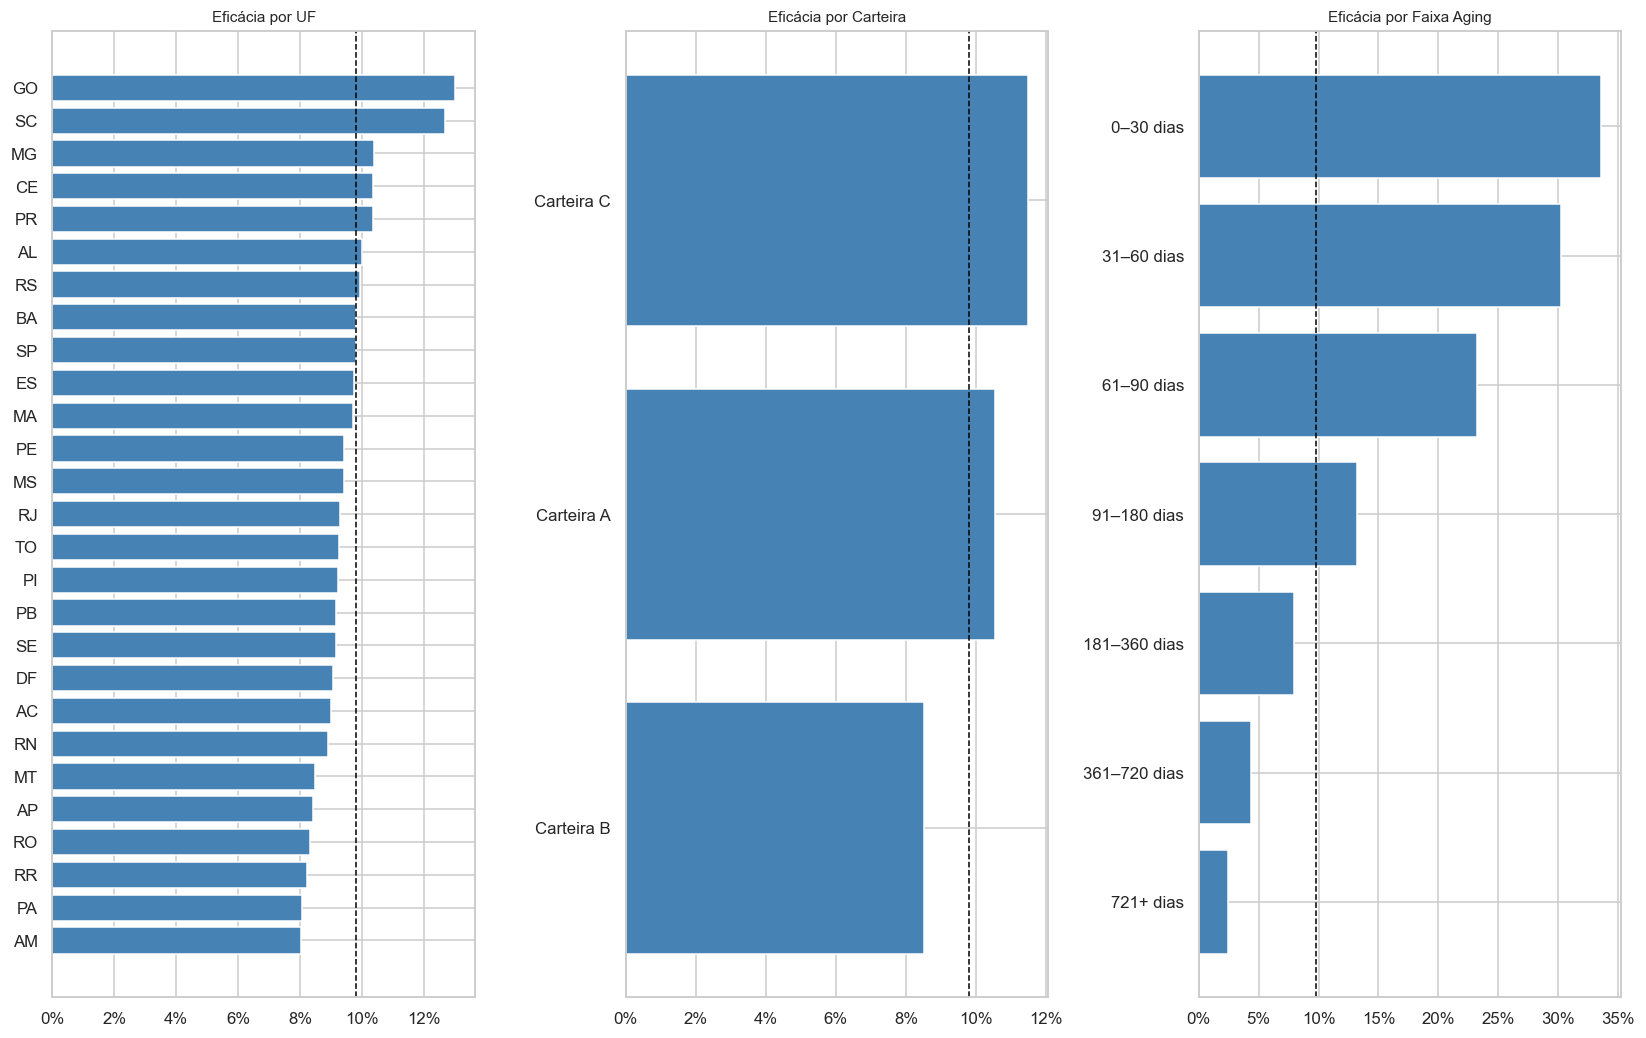

In [18]:
metrica = TAXA_PRINCIPAL or FEATURES[0]
fig, axes = plt.subplots(1, len(CATEGORIAS), figsize=(5 * len(CATEGORIAS), max(3.5, 0.3 * ent[CATEGORIAS].nunique().max() + 1.5)), squeeze=False)
for ax, c in zip(axes.flat, CATEGORIAS):
    serie = (perfil(ent, c)[metrica] if TAXA_PRINCIPAL else ent.groupby(c, observed=True)[metrica].mean()).sort_values()
    ax.barh(serie.index.astype(str), serie.to_numpy(), color="steelblue")
    ax.axvline(TAXA_GLOBAL if TAXA_PRINCIPAL else ent[metrica].mean(), color="black", ls="--", lw=1)
    ax.set_title(f"{metrica} por {c}", fontsize=10)
    eixo(ax, serie)
plt.tight_layout(); plt.show()

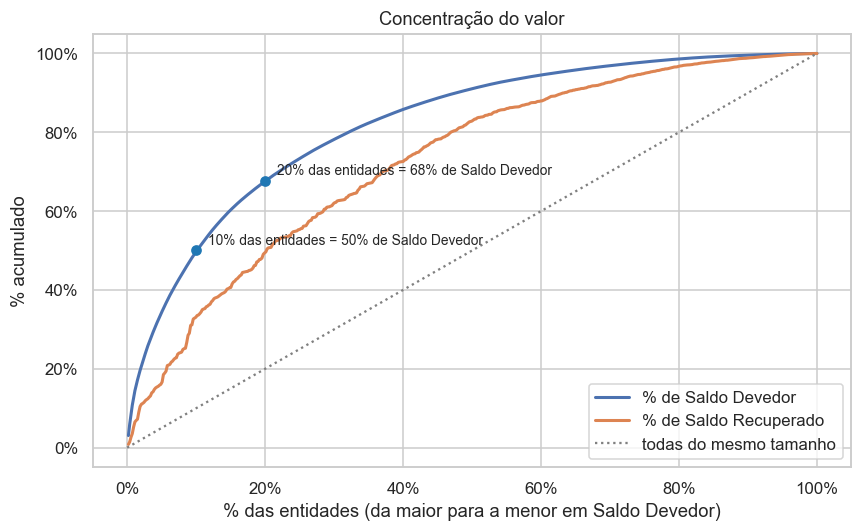

In [19]:
if PESO:
    x = np.arange(1, len(ordem) + 1) / len(ordem)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, acum.to_numpy(), lw=2, label=f"% de {PESO}")
    if TAXA_PRINCIPAL:
        ax.plot(x, (ordem[num].cumsum() / ordem[num].sum()).to_numpy(), lw=2, label=f"% de {num}")
    ax.plot([0, 1], [0, 1], color="gray", ls=":", label="todas do mesmo tamanho")
    for p in [0.10, 0.20]:
        y = acum.iloc[int(np.ceil(p * len(ordem))) - 1]
        ax.scatter(p, y, color="tab:blue", zorder=5)
        ax.annotate(f"{br_pct(p, 0)} das entidades = {br_pct(y, 0)} de {PESO}", (p, y), textcoords="offset points", xytext=(8, 4), fontsize=9)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0)); ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.set_xlabel(f"% das entidades (da maior para a menor em {PESO})"); ax.set_ylabel("% acumulado")
    ax.set_title("Concentração do valor"); ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()
else:
    print("Sem PESO na configuração: a curva de concentração não se aplica.")

## 8. Análises estatísticas e modelagem

Como no Mall, a modelagem sobe em **três camadas**: univariada (1 feature), bivariada (2) e multivariada (todas). Cada camada usa mais uma feature de `COLS_MODELO` — a lista de `FEATURES` já sem redundância, na ordem de prioridade da configuração. Se sobrar só 1 ou 2 features depois da seção 3, alguma camada acima repete a anterior; o notebook avisa quando isso acontece, em vez de fingir uma 3ª feature que não existe.

A camada multivariada é onde entram os três modelos não supervisionados, todos nas mesmas features padronizadas (média 0, desvio 1) para nenhuma dominar pela escala:

| Modelo | Como agrupa | De onde vem |
|---|---|---|
| **K-Means** | cada entidade vai para o centróide mais próximo; você escolhe o k | Mall, clusterização, RFM |
| **Hierárquico (Ward)** | junta, passo a passo, os dois grupos que menos aumentam a variação interna; o k é onde a árvore (dendrograma) é cortada | próximo passo sugerido no notebook de clusterização |
| **DBSCAN** | junta regiões densas e deixa os pontos isolados como **ruído** (−1), em vez de forçá-los para um grupo; não recebe k | clusterização |

Em todas as camadas, o k do K-Means (e do hierárquico) segue a mesma regra do RFM: o de maior silhouette entre os k ≥ `K_MINIMO` (com k = 2 os grupos costumam ser óbvios demais para gerar ações diferentes); `K_FIXO` fixa o mesmo k em todo lugar.

In [20]:
scaler = StandardScaler().fit(ent_m[COLS_MODELO])
X = scaler.transform(ent_m[COLS_MODELO])

def agrupa(modelo, X, k=None):
    if modelo == "K-Means": return KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X)
    if modelo == "Hierárquico": return AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)
    return DBSCAN(eps=eps, min_samples=min_amostras).fit_predict(X)

def inercia(X, rot):
    return sum(((X[rot == g] - X[rot == g].mean(axis=0)) ** 2).sum() for g in np.unique(rot))

def escolhe_k(Xc, modelo="K-Means"):
    b = pd.DataFrame([{"k": k, "inércia": inercia(Xc, r := agrupa(modelo, Xc, k)), "silhouette": silhouette_score(Xc, r)}
                      for k in range(2, min(10, len(Xc) - 1) + 1)])
    ok = b[b["k"] >= K_MINIMO] if (b["k"] >= K_MINIMO).any() else b
    return b, (int(K_FIXO) if K_FIXO else int(ok.loc[ok["silhouette"].idxmax(), "k"]))

def perfil_camada(rot, feats):
    return perfil(ent_m.assign(_c=rot), "_c", feats=feats)

### Camada univariada (1 feature)

Como no Mall: clusterizar uma única variável contínua com K-Means é, na prática, parecido com discretizá-la (`pd.cut`) — serve de referência, não de entrega. A feature é a 1ª de `COLS_MODELO`.

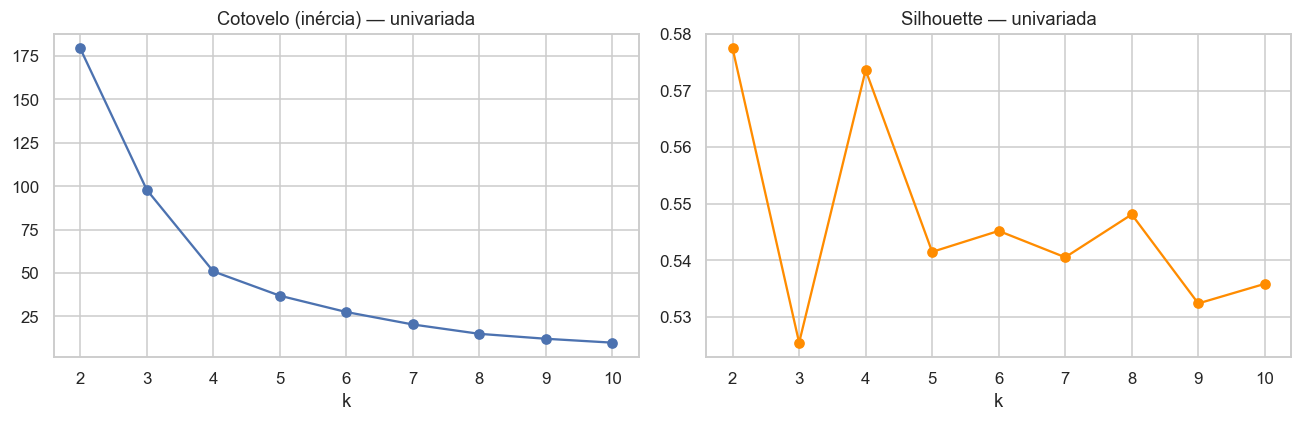

k escolhido: 4 (silhouette = 0,57) | feature: Peso Financeiro


,entidades,% entidades,% Saldo Devedor,Eficácia,Taxa ECS,Δ Eficácia vs global (p.p.),Δ Eficácia vs esperada por Faixa Aging (p.p.),média Peso Financeiro
_c,,,,,,,,
0,168,"31,6%","7,2%","18,2%","32,5%","+8,44 p.p.","+0,22 p.p.","0,043%"
1,86,"16,2%","62,2%","6,8%","12,4%","-2,98 p.p.","+0,02 p.p.","0,72%"
2,88,"16,5%","1,0%","24,2%","41,1%","+14,41 p.p.","+0,15 p.p.","0,011%"
3,190,"35,7%","29,6%","13,5%","24,3%","+3,75 p.p.","-0,10 p.p.","0,16%"


In [21]:
cols_uni = COLS_MODELO[:1]
X_uni = StandardScaler().fit_transform(ent_m[cols_uni])
busca_uni, k_uni = escolhe_k(X_uni)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(busca_uni["k"], busca_uni["inércia"], marker="o"); axes[0].set_title("Cotovelo (inércia) — univariada")
axes[1].plot(busca_uni["k"], busca_uni["silhouette"], marker="o", color="darkorange"); axes[1].set_title("Silhouette — univariada")
for ax in axes: ax.set_xlabel("k")
plt.tight_layout(); plt.show()

rot_uni = agrupa("K-Means", X_uni, k_uni)
sil_uni = busca_uni.loc[busca_uni["k"] == k_uni, "silhouette"].iloc[0]
print(f"k escolhido: {k_uni} (silhouette = {br_dec(sil_uni)}) | feature: {FEATURES_MODELO[0]}")
display(formata(perfil_camada(rot_uni, FEATURES_MODELO[:1])))

### Camada bivariada (2 features)

A camada de maior valor de negócio direto, como no Mall (renda × score de gasto): junta capacidade e comportamento em dois eixos. As duas primeiras features de `COLS_MODELO` — as mesmas da regra da seção 6. O ⭐ é o centróide (média de cada feature dentro do grupo).

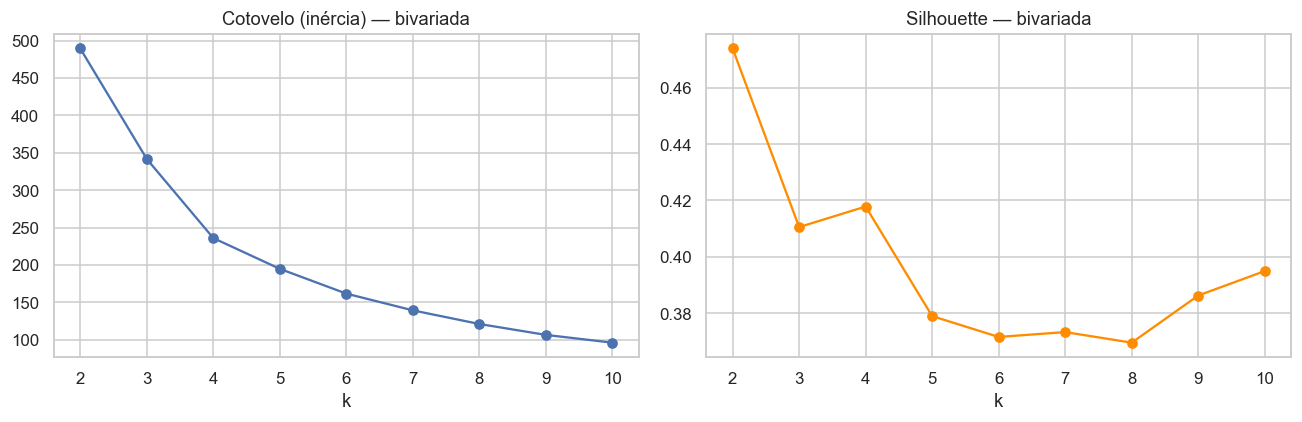

k escolhido: 4 (silhouette = 0,42) | features: Peso Financeiro, Eficácia


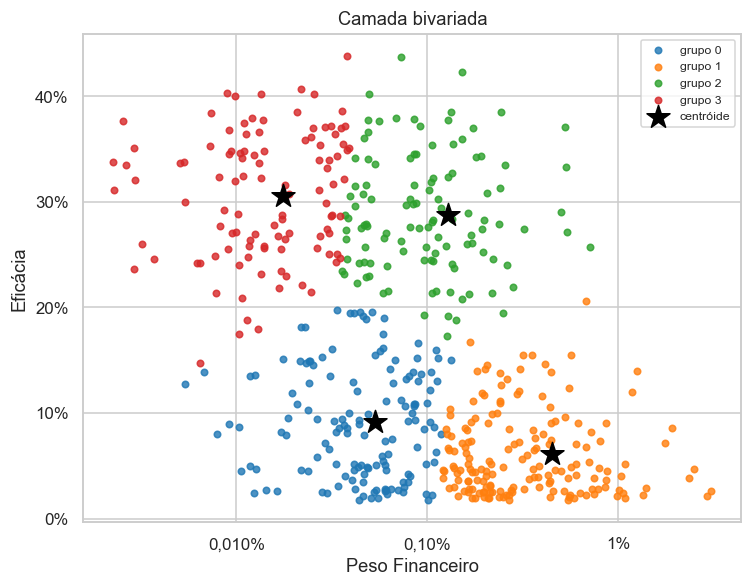

,entidades,% entidades,% Saldo Devedor,Eficácia,Taxa ECS,Δ Eficácia vs global (p.p.),Δ Eficácia vs esperada por Faixa Aging (p.p.),média Peso Financeiro
_c,,,,,,,,
0,141,"26,5%","7,5%","9,1%","15,1%","-0,69 p.p.","-0,10 p.p.","0,053%"
1,169,"31,8%","76,0%","5,7%","9,8%","-4,11 p.p.","-0,04 p.p.","0,45%"
2,114,"21,4%","14,6%","28,8%","47,7%","+19,00 p.p.","+0,10 p.p.","0,13%"
3,108,"20,3%","1,9%","31,2%","51,8%","+21,44 p.p.","+1,16 p.p.","0,018%"


In [22]:
if len(COLS_MODELO) >= 2:
    cols_bi = COLS_MODELO[:2]
    X_bi = StandardScaler().fit_transform(ent_m[cols_bi])
    busca_bi, k_bi = escolhe_k(X_bi)
    rot_bi = agrupa("K-Means", X_bi, k_bi)
    sil_bi = busca_bi.loc[busca_bi["k"] == k_bi, "silhouette"].iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(busca_bi["k"], busca_bi["inércia"], marker="o"); axes[0].set_title("Cotovelo (inércia) — bivariada")
    axes[1].plot(busca_bi["k"], busca_bi["silhouette"], marker="o", color="darkorange"); axes[1].set_title("Silhouette — bivariada")
    for ax in axes: ax.set_xlabel("k")
    plt.tight_layout(); plt.show()
    print(f"k escolhido: {k_bi} (silhouette = {br_dec(sil_bi)}) | features: {', '.join(FEATURES_MODELO[:2])}")

    fig, ax = plt.subplots(figsize=(7, 5.5))
    fx, fy = FEATURES_MODELO[0], FEATURES_MODELO[1]
    for g, cor in zip(range(k_bi), sns.color_palette("tab10", k_bi)):
        ax.scatter(ent_m.loc[rot_bi == g, fx], ent_m.loc[rot_bi == g, fy], s=18, alpha=0.8, color=cor, label=f"grupo {g}")
    centros_bi = ent_m.groupby(rot_bi)[[fx, fy]].mean()
    ax.scatter(centros_bi[fx], centros_bi[fy], s=250, c="black", marker="*", label="centróide")
    if fx in LOG: ax.set_xscale("log")
    if fy in LOG: ax.set_yscale("log")
    eixo(ax, ent_m[fx]); eixo(ax, ent_m[fy], "y")
    ax.set_xlabel(fx); ax.set_ylabel(fy); ax.set_title("Camada bivariada"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    display(formata(perfil_camada(rot_bi, FEATURES_MODELO[:2])))
else:
    print("Só 1 feature sobrou depois da redundância: a camada bivariada repete a univariada.")
    cols_bi, rot_bi, k_bi, sil_bi = cols_uni, rot_uni, k_uni, sil_uni

### Camada multivariada: os três modelos

Usa todas as `COLS_MODELO` (quando só sobraram 2 features depois da redundância, como na base de exemplo, esta camada repete a bivariada — a diferença aparece em tabelas com 3 ou mais features não redundantes, como a RFM).

### Escolha de k (K-Means e hierárquico)

Mesma regra das camadas anteriores, agora testando k de 2 a 10 para os dois modelos que precisam dele.

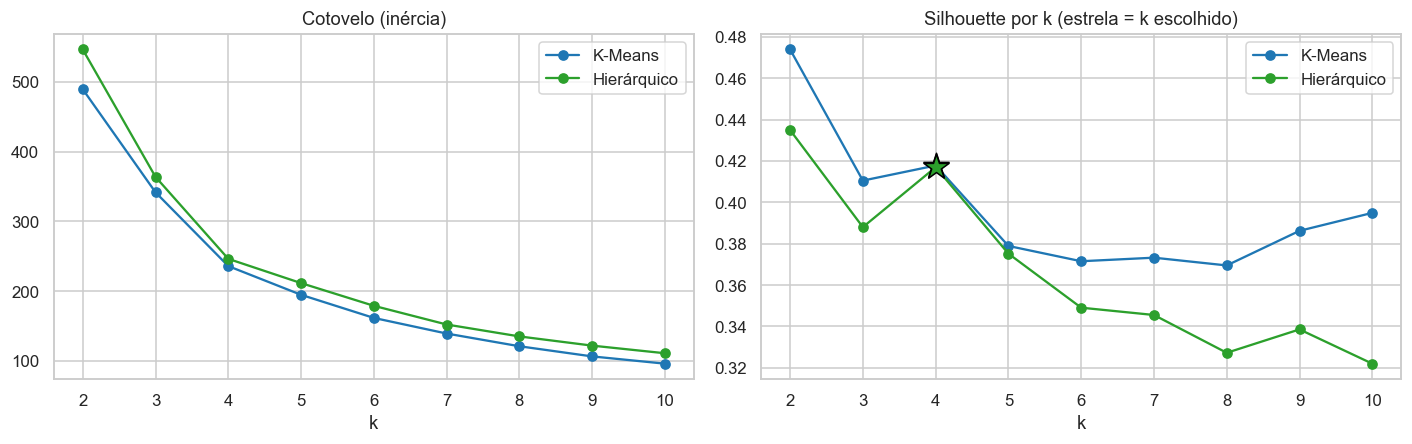

K-Means: k = 4 | Hierárquico: k = 4 (maior silhouette com k ≥ 3)


In [23]:
K_ESCOLHIDO, buscas = {}, []
for m in ["K-Means", "Hierárquico"]:
    b, K_ESCOLHIDO[m] = escolhe_k(X, m)
    b["modelo"] = m
    buscas.append(b)
busca = pd.concat(buscas, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for (m, b), cor in zip(busca.groupby("modelo", sort=False), ["tab:blue", "tab:green"]):
    axes[0].plot(b["k"], b["inércia"], marker="o", color=cor, label=m)
    axes[1].plot(b["k"], b["silhouette"], marker="o", color=cor, label=m)
    axes[1].scatter(K_ESCOLHIDO[m], b.loc[b["k"] == K_ESCOLHIDO[m], "silhouette"], marker="*", s=300, color=cor, edgecolor="black", zorder=5)
axes[0].set_title("Cotovelo (inércia)"); axes[1].set_title("Silhouette por k (estrela = k escolhido)")
for ax in axes: ax.set_xlabel("k"); ax.legend()
plt.tight_layout(); plt.show()
print(" | ".join(f"{m}: k = {k}" for m, k in K_ESCOLHIDO.items()) + (" (fixado à mão)" if K_FIXO else f" (maior silhouette com k ≥ {K_MINIMO})"))

### Dendrograma (hierárquico)

A árvore do modelo hierárquico mostra as últimas 30 junções. Quanto mais alta a junção, mais diferentes eram os dois grupos que se juntaram. A linha vermelha é o corte no k escolhido. Um salto grande logo acima do corte indica que os grupos abaixo dele são bem separados.

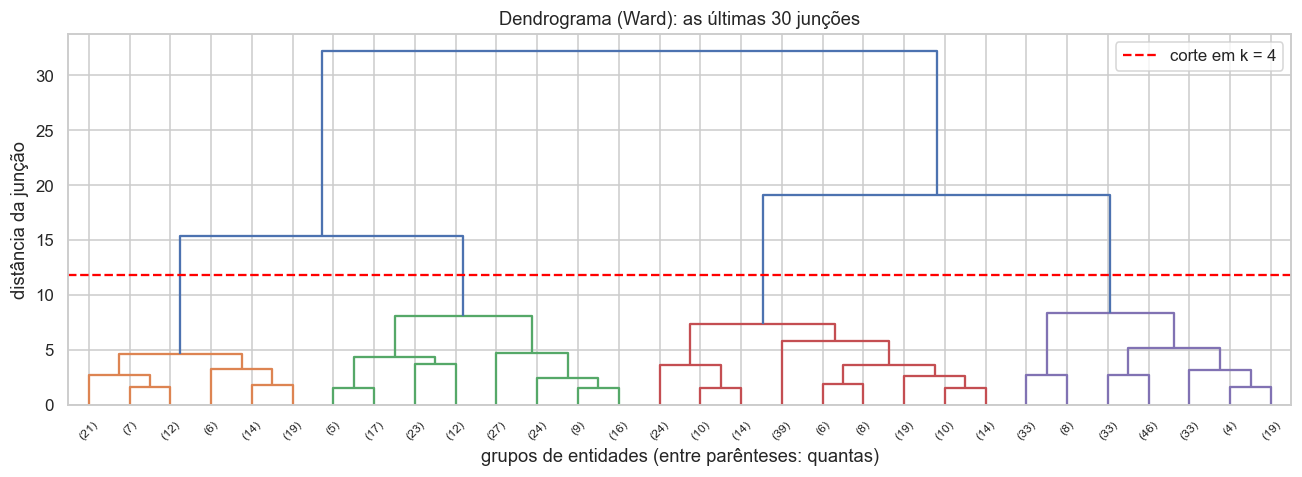

In [24]:
Z = linkage(X, method="ward")
k_h = K_ESCOLHIDO["Hierárquico"]
corte = (Z[-k_h, 2] + Z[-(k_h - 1), 2]) / 2
fig, ax = plt.subplots(figsize=(12, 4.5))
dendrogram(Z, truncate_mode="lastp", p=30, ax=ax, color_threshold=corte, leaf_font_size=8)
ax.axhline(corte, color="red", ls="--", label=f"corte em k = {k_h}")
ax.set_title("Dendrograma (Ward): as últimas 30 junções")
ax.set_ylabel("distância da junção"); ax.set_xlabel("grupos de entidades (entre parênteses: quantas)")
ax.legend(); plt.tight_layout(); plt.show()

### DBSCAN: densidade em vez de centróides

O DBSCAN tem dois parâmetros:

- `DBSCAN_MIN_AMOSTRAS`: quantos vizinhos um ponto precisa ter para estar numa região densa. O padrão é 2 × nº de features, uma regra de bolso comum.
- `DBSCAN_EPS`: o que conta como "perto". Ele sai do **gráfico de k-distância**, que mostra a distância de cada entidade até o seu vizinho de número `MIN_AMOSTRAS`, em ordem. O eps é o ponto em que a curva dobra para cima, achado automaticamente como o ponto mais distante da reta entre o começo e o fim da curva.

Para fixar os dois à mão, use a configuração dos modelos.

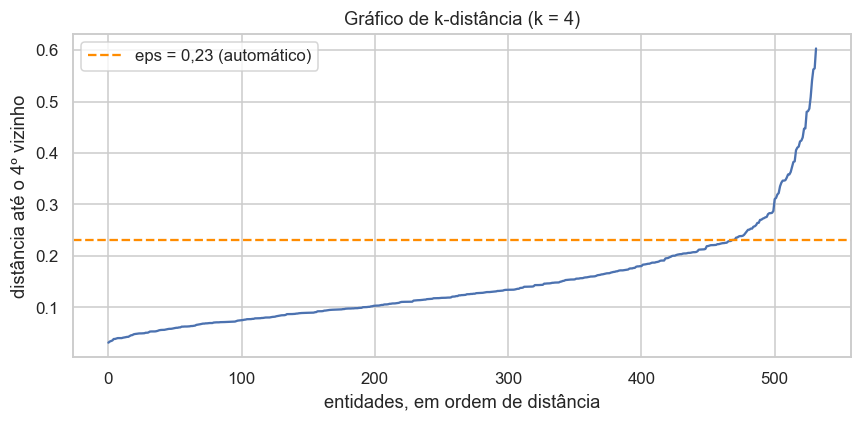

DBSCAN: 7 grupo(s) + 32 entidades de ruído (6,0%)
Leitura: o maior grupo do DBSCAN tem 85,4% das entidades que não são ruído. Não há regiões densas bem separadas; as entidades formam um contínuo. Aqui o DBSCAN funciona como detector de atípicos (o ruído), não como segmentação.


In [25]:
min_amostras = DBSCAN_MIN_AMOSTRAS or 2 * X.shape[1]
dist = np.sort(NearestNeighbors(n_neighbors=min_amostras).fit(X).kneighbors(X)[0][:, -1])
xn, yn = np.linspace(0, 1, len(dist)), (dist - dist[0]) / (dist[-1] - dist[0])
eps = DBSCAN_EPS or float(dist[np.argmax(xn - yn)])
rot_db = agrupa("DBSCAN", X)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dist)
ax.axhline(eps, color="darkorange", ls="--", label=f"eps = {br_dec(eps)} ({'fixado' if DBSCAN_EPS else 'automático'})")
ax.set_title(f"Gráfico de k-distância (k = {min_amostras})")
ax.set_xlabel("entidades, em ordem de distância"); ax.set_ylabel(f"distância até o {min_amostras}º vizinho")
ax.legend(); plt.tight_layout(); plt.show()
n_db, ruido = len(set(rot_db) - {-1}), rot_db == -1
print(f"DBSCAN: {n_db} grupo(s) + {ruido.sum()} entidades de ruído ({br_pct(ruido.mean())})")
maior = pd.Series(rot_db[~ruido]).value_counts(normalize=True).max() if n_db else 1.0
if n_db <= 1 or maior >= 0.8:
    print(f"Leitura: o maior grupo do DBSCAN tem {br_pct(maior)} das entidades que não são ruído. Não há regiões densas bem separadas; "
          "as entidades formam um contínuo. Aqui o DBSCAN funciona como detector de atípicos (o ruído), não como segmentação.")

### Comparação dos três modelos

A tabela resume cada modelo:

- **Grupos, % de ruído e silhouette.** No DBSCAN, o silhouette é calculado sem o ruído.
- **ARI entre os modelos.** 1 quer dizer que agrupam igual, e 0 quer dizer que a coincidência é a do acaso. Quando modelos com lógicas diferentes concordam, os grupos são mais confiáveis.

O gráfico mostra as mesmas entidades coloridas por cada modelo:

- **Com 2 features:** no plano das próprias features.
- **Com 3 ou mais:** no **PCA** (2 eixos, do notebook de clusterização).

O modelo usado daqui em diante é o `MODELO_FINAL`.

,grupos,% ruído,silhouette,ARI com K-Means,ARI com Hierárquico,ARI com DBSCAN
K-Means,4,"0,0%","0,42","1,00","0,82","0,10"
Hierárquico,4,"0,0%","0,42","0,82","1,00","0,07"
DBSCAN,7,"6,0%","0,00","0,10","0,07","1,00"


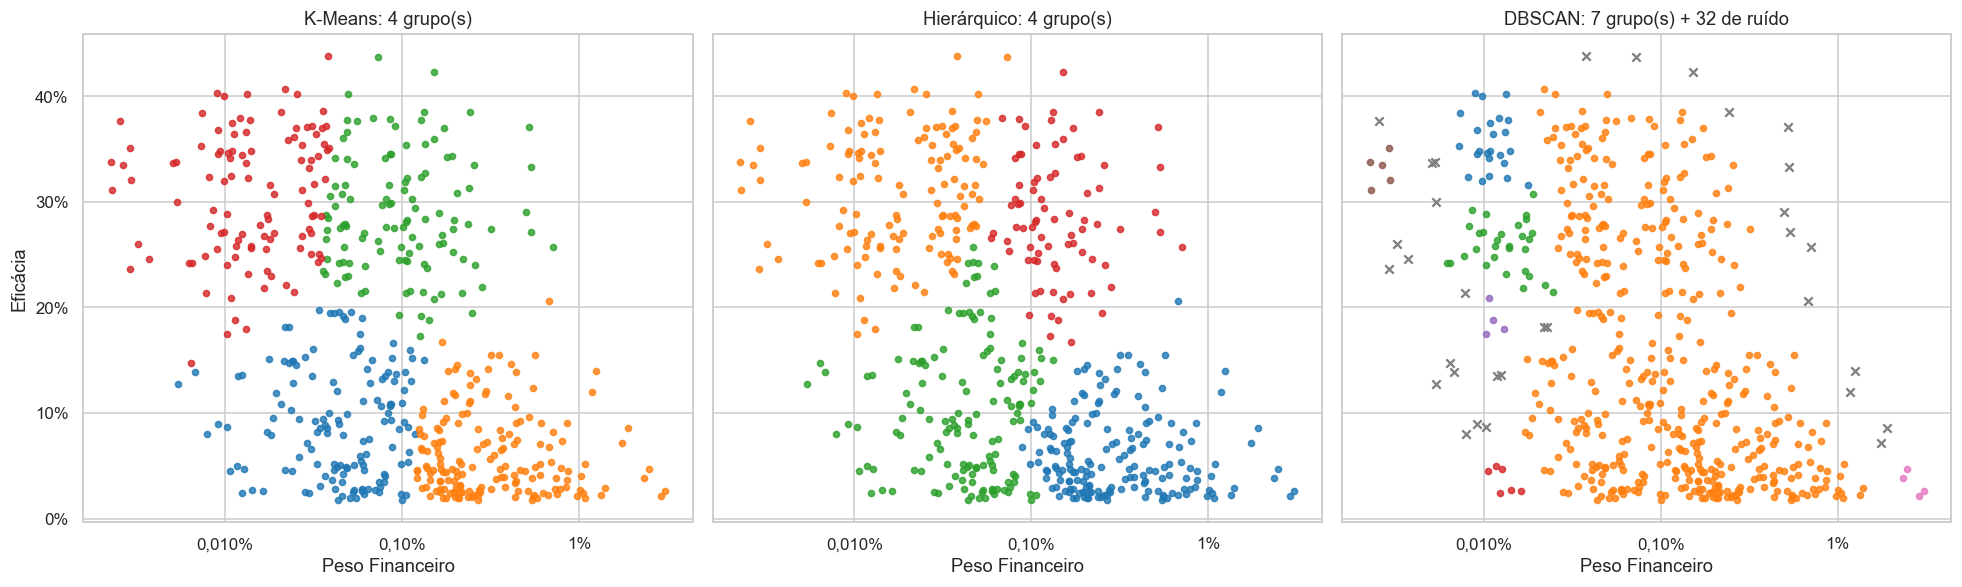

In [26]:
ROTULOS = {"K-Means": agrupa("K-Means", X, K_ESCOLHIDO["K-Means"]),
           "Hierárquico": agrupa("Hierárquico", X, K_ESCOLHIDO["Hierárquico"]), "DBSCAN": rot_db}
def sil(rot):
    m = rot != -1
    return silhouette_score(X[m], rot[m]) if len(set(rot[m])) >= 2 else np.nan
comp = pd.DataFrame({m: {"grupos": len(set(r) - {-1}), "% ruído": (r == -1).mean(), "silhouette": sil(r)} for m, r in ROTULOS.items()}).T
for m in ROTULOS:
    comp[f"ARI com {m}"] = [adjusted_rand_score(ROTULOS[m], r) for r in ROTULOS.values()]
comp["grupos"] = comp["grupos"].astype(int)
display(comp.style.format({c: br_dec for c in comp.columns if c not in ("grupos", "% ruído")} | {"% ruído": br_pct}))

if len(COLS_MODELO) == 2:
    xy, rot_eixos = ent_m[FEATURES_MODELO].to_numpy(float), FEATURES_MODELO
else:
    pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(X)
    xy, rot_eixos = pca.transform(X), [f"PC1 ({br_pct(pca.explained_variance_ratio_[0], 0)})", f"PC2 ({br_pct(pca.explained_variance_ratio_[1], 0)})"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True)
for ax, (m, r) in zip(axes, ROTULOS.items()):
    for g, cor in zip(sorted(set(r) - {-1}), sns.color_palette("tab10", 10)):
        ax.scatter(xy[r == g, 0], xy[r == g, 1], s=16, alpha=0.8, color=cor)
    ax.scatter(xy[r == -1, 0], xy[r == -1, 1], s=30, marker="x", color="gray", label="ruído")
    ax.set_title(f"{m}: {len(set(r) - {-1})} grupo(s)" + (f" + {int((r == -1).sum())} de ruído" if (r == -1).any() else ""))
    ax.set_xlabel(rot_eixos[0])
    if len(COLS_MODELO) == 2:
        if FEATURES_MODELO[0] in LOG: ax.set_xscale("log")
        if FEATURES_MODELO[1] in LOG: ax.set_yscale("log")
        eixo(ax, ent_m[FEATURES_MODELO[0]]); eixo(ax, ent_m[FEATURES_MODELO[1]], "y")
axes[0].set_ylabel(rot_eixos[1])
plt.tight_layout(); plt.show()

### Modelo final: grupos, nomes e perfil

Os nomes vêm do centro de cada grupo, como no RFM, e não do número que o algoritmo deu:

- **↑ ou ↓:** o centro fica acima ou abaixo da média das entidades em cada feature (a mesma referência do heatmap). Com mais de 3 features, entram só as 2 que mais se afastam da média.
- **Número G1, G2…:** segue o valor (`PESO`), ou o tamanho do grupo quando não há `PESO`. G1 é o maior.
- **Ruído:** no DBSCAN, o ruído aparece como um grupo à parte, no fim.

In [27]:
ent_m["_cluster"] = ROTULOS[MODELO_FINAL]
centros = pd.DataFrame(X, columns=COLS_MODELO).groupby(ent_m["_cluster"].to_numpy()).mean()
def nome_do_grupo(c):
    if c == -1: return "ruído (atípicos do DBSCAN)"
    cols = COLS_MODELO if len(COLS_MODELO) <= 3 else centros.loc[c].abs().nlargest(2).index
    return " · ".join(f"{NOME_MODELO[f]} {'↑' if centros.loc[c, f] >= 0 else '↓'}" for f in cols)   # 0 = média
tamanho = ent_m.groupby("_cluster")[PESO].sum() if PESO else ent_m.groupby("_cluster").size()
ordem = [c for c in tamanho.sort_values(ascending=False).index if c != -1] + ([-1] if -1 in tamanho.index else [])
NOMES = {c: (f"G{i + 1}: " if c != -1 else "") + nome_do_grupo(c) for i, c in enumerate(ordem)}
ent_m["Grupo"] = pd.Categorical(ent_m["_cluster"].map(NOMES), categories=[NOMES[c] for c in ordem])
K = len(ordem)
print(f"Modelo final: {MODELO_FINAL}, {K} grupo(s)")
perfil_grupos = perfil(ent_m, "Grupo")
formata(perfil_grupos)

Modelo final: K-Means, 4 grupo(s)


,entidades,% entidades,% Saldo Devedor,Eficácia,Taxa ECS,Δ Eficácia vs global (p.p.),Δ Eficácia vs esperada por Faixa Aging (p.p.),média Peso Financeiro,média Peso ECS
Grupo,,,,,,,,,
G1: Peso Financeiro ↑ · Eficácia ↓,169,"31,8%","76,0%","5,7%","9,8%","-4,11 p.p.","-0,04 p.p.","0,45%","0,41%"
G2: Peso Financeiro ↑ · Eficácia ↑,114,"21,4%","14,6%","28,8%","47,7%","+19,00 p.p.","+0,10 p.p.","0,13%","0,16%"
G3: Peso Financeiro ↓ · Eficácia ↓,141,"26,5%","7,5%","9,1%","15,1%","-0,69 p.p.","-0,10 p.p.","0,053%","0,065%"
G4: Peso Financeiro ↓ · Eficácia ↑,108,"20,3%","1,9%","31,2%","51,8%","+21,44 p.p.","+1,16 p.p.","0,018%","0,030%"


In [28]:
if len(COLS_MODELO) > 2:
    z = centros.loc[ordem].set_axis([NOMES[c] for c in ordem]).set_axis(FEATURES_MODELO, axis=1)
    medias = ent_m.groupby("Grupo", observed=True)[FEATURES_MODELO].mean()
    anot = medias.apply(lambda s: s.map(br_pct) if e_fracao(ent_m[s.name]) else s.map(lambda v: br_num(v, 1)))
    fig, ax = plt.subplots(figsize=(max(11, 1.8 * len(COLS_MODELO) + 7), 0.6 * K + 2.5))
    sns.heatmap(z, annot=anot.to_numpy(), fmt="", cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "desvios-padrão"})
    ax.set_title(f"Perfil dos grupos, {MODELO_FINAL} (cor: desvios-padrão; número: média original)"); ax.set_ylabel("")
    plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

### Regras × modelo final

A tabela cruzada do notebook de clusterização. Quando um grupo do modelo se concentra numa regra, o algoritmo achou sozinho a categoria que você escreveria à mão. Onde os dois discordam estão as entidades limítrofes. O **ARI** resume a concordância.

**Os grupos são uma categoria com outro nome?** É o perfil categórico do Mall (a % de gênero por cluster), feito para cada coluna de `CATEGORIAS`, com o **V de Cramér** para resumir a força da associação. A escala vai de 0 (nenhuma) a 1 (o grupo **é** a categoria). Acima de ~0,5, vale perguntar se o modelo trouxe algo além daquela categoria. Nesse caso, o Δ contra a referência, no perfil, ajuda a responder.

In [29]:
display(pd.crosstab(ent_m["Grupo"], ent_m["Segmento por regra"], margins=True, margins_name="total"))
print(f"ARI regras × {MODELO_FINAL}: {br_dec(adjusted_rand_score(ent_m['Segmento por regra'], ent_m['_cluster']))}")

Segmento por regra,Peso Financeiro ↑ · Eficácia ↑,Peso Financeiro ↑ · Eficácia ↓,Peso Financeiro ↓ · Eficácia ↑,Peso Financeiro ↓ · Eficácia ↓,total
Grupo,,,,,
G1: Peso Financeiro ↑ · Eficácia ↓,12,157,0,0,169
G2: Peso Financeiro ↑ · Eficácia ↑,69,0,45,0,114
G3: Peso Financeiro ↓ · Eficácia ↓,7,21,25,88,141
G4: Peso Financeiro ↓ · Eficácia ↑,0,0,108,0,108
total,88,178,178,88,532


ARI regras × K-Means: 0,57


In [30]:
def cramer_v(a, b):
    tab = pd.crosstab(a, b)
    chi2, p, gl, esperado = stats.chi2_contingency(tab)
    return np.sqrt(chi2 / (tab.to_numpy().sum() * (min(tab.shape) - 1))), p, (esperado < 5).mean()

assoc = {}
for c in CATEGORIAS:
    display(Markdown(f"**{c}: % de cada grupo em cada categoria**"))
    display(pd.crosstab(ent_m["Grupo"], ent_m[c], normalize="index").style.format(br_pct))
    assoc[c] = dict(zip(["V de Cramér", "p", "% células com esperado < 5"], cramer_v(ent_m["Grupo"], ent_m[c])))
assoc = pd.DataFrame(assoc).T
assoc.style.format({"V de Cramér": lambda v: br_dec(v, 3), "p": lambda p: "< 0,0001" if p < 1e-4 else br_dec(p, 4),
                    "% células com esperado < 5": br_pct})

**UF: % de cada grupo em cada categoria**

UF,AC,AL,AM,AP,BA,CE,DF,ES,GO,MA,MG,MS,MT,PA,PB,PE,PI,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO
Grupo,,,,,,,,,,,,,,,,,,,,,,,,,,,
G1: Peso Financeiro ↑ · Eficácia ↓,"0,0%","3,0%","3,6%","0,0%","6,5%","5,3%","1,8%","3,6%","3,6%","4,7%","7,1%","2,4%","3,6%","5,9%","3,6%","5,3%","3,6%","6,5%","6,5%","3,6%","0,0%","0,0%","6,5%","3,6%","2,4%","7,7%","0,0%"
G2: Peso Financeiro ↑ · Eficácia ↑,"0,0%","0,88%","4,4%","0,0%","7,9%","6,1%","0,88%","4,4%","5,3%","5,3%","7,9%","0,0%","2,6%","5,3%","4,4%","5,3%","3,5%","6,1%","7,9%","3,5%","0,0%","0,0%","6,1%","5,3%","0,0%","7,0%","0,0%"
G3: Peso Financeiro ↓ · Eficácia ↓,"7,8%","5,0%","3,5%","7,1%","0,71%","1,4%","6,4%","4,3%","2,1%","2,1%","0,0%","4,3%","4,3%","0,71%","4,3%","0,71%","5,0%","0,71%","0,71%","5,0%","8,5%","8,5%","0,71%","1,4%","6,4%","0,0%","8,5%"
G4: Peso Financeiro ↓ · Eficácia ↑,"8,3%","6,5%","2,8%","8,3%","0,0%","1,9%","5,6%","2,8%","2,8%","2,8%","0,0%","6,5%","2,8%","1,9%","2,8%","1,9%","3,7%","1,9%","0,0%","3,7%","7,4%","8,3%","1,9%","2,8%","6,5%","0,0%","6,5%"


**Carteira: % de cada grupo em cada categoria**

Carteira,Carteira A,Carteira B,Carteira C
Grupo,,,
G1: Peso Financeiro ↑ · Eficácia ↓,"41,4%","42,0%","16,6%"
G2: Peso Financeiro ↑ · Eficácia ↑,"46,5%","39,5%","14,0%"
G3: Peso Financeiro ↓ · Eficácia ↓,"21,3%","27,0%","51,8%"
G4: Peso Financeiro ↓ · Eficácia ↑,"22,2%","18,5%","59,3%"


**Faixa Aging: % de cada grupo em cada categoria**

Faixa Aging,0–30 dias,31–60 dias,61–90 dias,91–180 dias,181–360 dias,361–720 dias,721+ dias
Grupo,,,,,,,
G1: Peso Financeiro ↑ · Eficácia ↓,"0,0%","0,0%","0,59%","15,4%","24,9%","29,0%","30,2%"
G2: Peso Financeiro ↑ · Eficácia ↑,"32,5%","33,3%","34,2%","0,0%","0,0%","0,0%","0,0%"
G3: Peso Financeiro ↓ · Eficácia ↓,"0,0%","0,0%","7,8%","33,3%","23,4%","19,1%","16,3%"
G4: Peso Financeiro ↓ · Eficácia ↑,"38,9%","35,2%","25,0%","0,93%","0,0%","0,0%","0,0%"


,V de Cramér,p,% células com esperado < 5
UF,"0,405","< 0,0001","54,6%"
Carteira,"0,299","< 0,0001","0,0%"
Faixa Aging,"0,575","< 0,0001","0,0%"


### Quanto cada categoria explica da taxa principal

Uma regressão da taxa das entidades em todas as `CATEGORIAS` juntas, com ANOVA tipo II:

- **Pesos:** a regressão é ponderada pelo denominador da taxa (WLS). Uma entidade grande pesa mais, como na taxa global.
- **R²:** quanto da variação as categorias explicam juntas.
- **η² parcial:** quanto cada uma explica, descontadas as outras. Como guia (Cohen), 0,01 é pequeno, 0,06 é médio e 0,14 é grande.

Sem `TAXA_PRINCIPAL`, a regressão usa a primeira feature, sem pesos. Categorias aninhadas (uma dentro da outra, como UF dentro de uma região) não devem entrar juntas em `CATEGORIAS`.

Os dados são a população inteira, não uma amostra, e entidades parecidas não são independentes. Por isso vale olhar o tamanho do efeito mais do que o p-valor.

**Estabilidade:** os grupos do modelo final se repetem se a base mudar um pouco? O teste faz 30 sorteios de 80% das entidades, refaz o modelo em cada um e mede o ARI contra os grupos originais nas mesmas entidades. Acima de 0,8 o agrupamento é estável; abaixo de 0,6, é melhor tratar os grupos como aproximados.

In [31]:
alvo = TAXA_PRINCIPAL or COLS_MODELO[0]
cats = [c for c in CATEGORIAS if 2 <= ent_m[c].nunique() <= 50]
eta = pd.Series(dtype=float)
if cats:
    base = ent_m.rename(columns={alvo: "_y"})
    pesos = base[TAXAS[TAXA_PRINCIPAL][1]] / base[TAXAS[TAXA_PRINCIPAL][1]].mean() if TAXA_PRINCIPAL else pd.Series(1.0, index=base.index)
    mod = smf.wls("_y ~ " + " + ".join(f'C(Q("{c}"))' for c in cats), data=base, weights=pesos).fit()
    aov = anova_lm(mod, typ=2)
    eta = (aov["sum_sq"] / (aov["sum_sq"] + aov.loc["Residual", "sum_sq"])).drop("Residual")
    eta.index = cats
    print(f"R² {'ponderado ' if TAXA_PRINCIPAL else ''}de {alvo} explicado por {', '.join(cats)}: {br_dec(mod.rsquared, 3)}")
    display(eta.to_frame("η² parcial").style.format(lambda v: br_dec(v, 3)))
else:
    print("Nenhuma categoria com 2 a 50 valores: a regressão não se aplica.")

R² ponderado de Eficácia explicado por UF, Carteira, Faixa Aging: 0,983


,η² parcial
UF,"0,161"
Carteira,"0,455"
Faixa Aging,"0,982"


In [32]:
rng, aris = np.random.default_rng(RANDOM_STATE), []
for _ in range(30):
    idx = rng.choice(len(X), int(0.8 * len(X)), replace=False)
    aris.append(adjusted_rand_score(ROTULOS[MODELO_FINAL][idx], agrupa(MODELO_FINAL, X[idx], K_ESCOLHIDO.get(MODELO_FINAL))))
estab = pd.Series({"ARI médio": np.mean(aris), "ARI mínimo": np.min(aris), "ARI p5": np.percentile(aris, 5)})
estab.to_frame(f"valor ({MODELO_FINAL})").style.format(br_dec)

,valor (K-Means)
ARI médio,"0,93"
ARI mínimo,"0,81"
ARI p5,"0,86"


### Exportação

Uma linha por entidade, com as colunas da tabela, o grupo de cada modelo (número bruto; −1 é ruído do DBSCAN), o grupo do modelo final (com nome) e o segmento por regra. O arquivo usa separador `;` e vírgula decimal, então abre direto no Excel.

In [33]:
ARQUIVO_SAIDA = "entidades_segmentadas.csv"
for m, r in ROTULOS.items():
    ent_m[f"Grupo {m}"] = r
saida = ent_m[[c for c in ent_m.columns if not c.startswith(("_", "log "))]]
saida.to_csv(ARQUIVO_SAIDA, index=False, sep=";", decimal=",", encoding="utf-8-sig")
print(f"Exportado: {ARQUIVO_SAIDA} ({len(saida)} entidades)")

Exportado: entidades_segmentadas.csv (532 entidades)


## 9. Interpretação

### Perfil final e tamanho da oportunidade

O perfil dos grupos do modelo final (`MODELO_FINAL`), com duas colunas a mais quando há `REFERENCIA`:

- a **taxa esperada** pelas categorias de referência de cada entidade;
- o **numerador a mais** que o grupo teria nessa taxa esperada, isto é, Σ (denominador × taxa da referência) − Σ numerador, quando positivo.

É uma conta aritmética de tamanho, não uma previsão: não diz que é possível chegar lá nem como. A comparação é contra a referência, e não contra a taxa global, para não chamar de oportunidade o que é só mix.

Depois da tabela vêm os **painéis** e a **leitura de cada grupo**. Do RFM, sem eixo duplo. Um painel mostra a taxa principal (ou a média da primeira feature), e o outro compara, em %, o peso no valor com o peso no nº de entidades. Quando a barra passa muito do ponto, o grupo tem poucas entidades grandes. Gerada a partir dos números, como o resumo executivo do RFM. Por isso continua certa com qualquer tabela.

In [34]:
final = perfil_grupos.copy()
COL_OPORT = None
if REFERENCIA:
    a, b = TAXAS[TAXA_PRINCIPAL]
    somas = ent_m.groupby("Grupo", observed=True)[[a, b, "_esperado"]].sum()
    final.insert(final.columns.get_loc(TAXA_PRINCIPAL) + 1, f"{TAXA_PRINCIPAL} esperada", somas["_esperado"] / somas[b])
    COL_OPORT = f"{a} a mais na taxa esperada"
    final[COL_OPORT] = (somas["_esperado"] - somas[a]).clip(lower=0)
formata(final)

,entidades,% entidades,% Saldo Devedor,Eficácia,Eficácia esperada,Taxa ECS,Δ Eficácia vs global (p.p.),Δ Eficácia vs esperada por Faixa Aging (p.p.),média Peso Financeiro,média Peso ECS,Saldo Recuperado a mais na taxa esperada
Grupo,,,,,,,,,,,
G1: Peso Financeiro ↑ · Eficácia ↓,169,"31,8%","76,0%","5,7%","5,7%","9,8%","-4,11 p.p.","-0,04 p.p.","0,45%","0,41%",9.189.192
G2: Peso Financeiro ↑ · Eficácia ↑,114,"21,4%","14,6%","28,8%","28,7%","47,7%","+19,00 p.p.","+0,10 p.p.","0,13%","0,16%",0
G3: Peso Financeiro ↓ · Eficácia ↓,141,"26,5%","7,5%","9,1%","9,2%","15,1%","-0,69 p.p.","-0,10 p.p.","0,053%","0,065%",2.200.908
G4: Peso Financeiro ↓ · Eficácia ↑,108,"20,3%","1,9%","31,2%","30,1%","51,8%","+21,44 p.p.","+1,16 p.p.","0,018%","0,030%",0


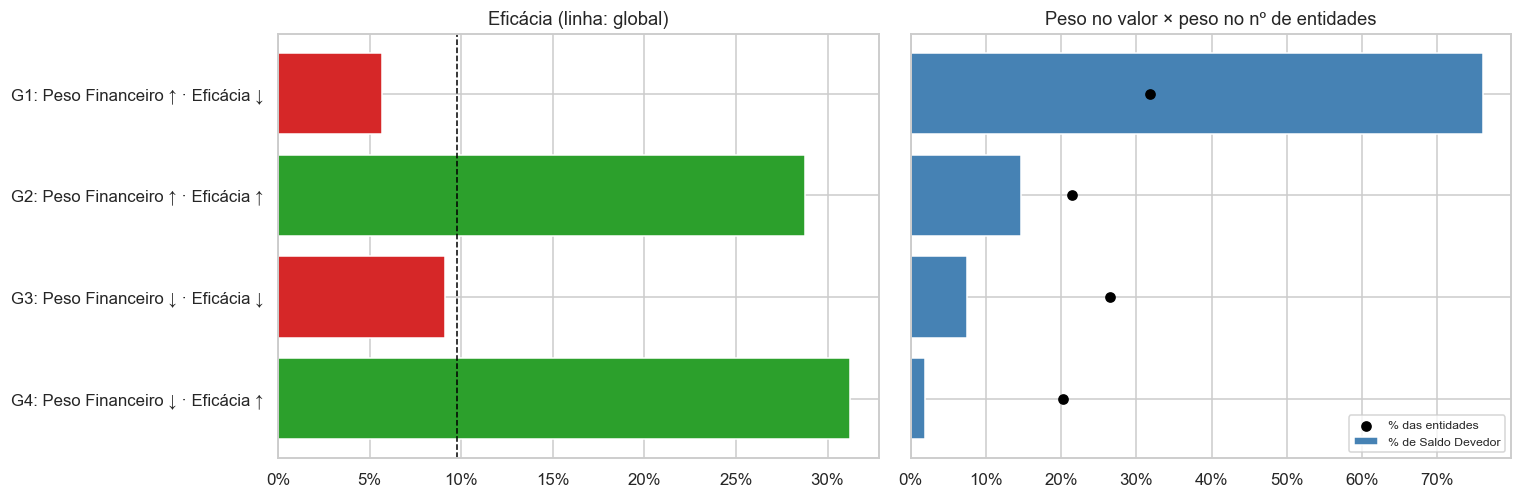

In [35]:
ordem_g = final.index[::-1].astype(str)
fig, axes = plt.subplots(1, 2, figsize=(14, 0.55 * K + 2.5), sharey=True)
if TAXA_PRINCIPAL:
    v = final[TAXA_PRINCIPAL].to_numpy()[::-1]
    axes[0].barh(ordem_g, v, color=["tab:green" if x >= TAXA_GLOBAL else "tab:red" for x in v])
    axes[0].axvline(TAXA_GLOBAL, color="black", ls="--", lw=1); axes[0].set_title(f"{TAXA_PRINCIPAL} (linha: global)")
    eixo(axes[0], final[TAXA_PRINCIPAL])
else:
    axes[0].barh(ordem_g, final[f"média {FEATURES[0]}"].to_numpy()[::-1], color="steelblue"); axes[0].set_title(f"média de {FEATURES[0]}")
if PESO:
    axes[1].barh(ordem_g, final[f"% {PESO}"].to_numpy()[::-1], color="steelblue", label=f"% de {PESO}")
axes[1].scatter(final["% entidades"].to_numpy()[::-1], ordem_g, color="black", zorder=5, label="% das entidades")
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0)); axes[1].legend(loc="lower right", fontsize=8)
axes[1].set_title("Peso no valor × peso no nº de entidades")
plt.tight_layout(); plt.show()

In [36]:
col_delta_ref = f"Δ {TAXA_PRINCIPAL} vs esperada por {REFERENCIA} (p.p.)" if REFERENCIA else None
linhas = []
for nome, r in final.iterrows():
    t = f"- **{nome}**: {int(r['entidades'])} entidades ({br_pct(r['% entidades'])})"
    t += f", com {br_pct(r[f'% {PESO}'])} de {PESO}." if PESO else "."
    if TAXA_PRINCIPAL:
        t += f" {TAXA_PRINCIPAL} de {br_pct(r[TAXA_PRINCIPAL])} ({br_pp(r[f'Δ {TAXA_PRINCIPAL} vs global (p.p.)'])} contra a global"
        t += f"; {br_pp(r[col_delta_ref])} contra o esperado por {REFERENCIA})." if REFERENCIA else ")."
        if REFERENCIA and abs(r[col_delta_ref]) < 0.5 <= abs(r[f"Δ {TAXA_PRINCIPAL} vs global (p.p.)"]):
            t += f" A diferença para a global vem do mix de {REFERENCIA}, não do desempenho."
    if COL_OPORT and r[COL_OPORT] > 0:
        t += f" Na taxa esperada, teria {br_num(r[COL_OPORT])} a mais de {TAXAS[TAXA_PRINCIPAL][0]}."
    linhas.append(t)
display(Markdown("\n".join(linhas)))

- **G1: Peso Financeiro ↑ · Eficácia ↓**: 169 entidades (31,8%), com 76,0% de Saldo Devedor. Eficácia de 5,7% (-4,11 p.p. contra a global; -0,04 p.p. contra o esperado por Faixa Aging). A diferença para a global vem do mix de Faixa Aging, não do desempenho. Na taxa esperada, teria 9.189.192 a mais de Saldo Recuperado.
- **G2: Peso Financeiro ↑ · Eficácia ↑**: 114 entidades (21,4%), com 14,6% de Saldo Devedor. Eficácia de 28,8% (+19,00 p.p. contra a global; +0,10 p.p. contra o esperado por Faixa Aging). A diferença para a global vem do mix de Faixa Aging, não do desempenho.
- **G3: Peso Financeiro ↓ · Eficácia ↓**: 141 entidades (26,5%), com 7,5% de Saldo Devedor. Eficácia de 9,1% (-0,69 p.p. contra a global; -0,10 p.p. contra o esperado por Faixa Aging). A diferença para a global vem do mix de Faixa Aging, não do desempenho. Na taxa esperada, teria 2.200.908 a mais de Saldo Recuperado.
- **G4: Peso Financeiro ↓ · Eficácia ↑**: 108 entidades (20,3%), com 1,9% de Saldo Devedor. Eficácia de 31,2% (+21,44 p.p. contra a global; +1,16 p.p. contra o esperado por Faixa Aging).

## 10. Insights finais

Os pontos da célula abaixo saem das tabelas acima, e não são texto fixo. As limitações valem para qualquer tabela.

### Limitações

- **Sem causa.** Os grupos e os testes mostram associação. Um grupo ter taxa menor não diz por quê.
- **Cada entidade vale um ponto nos modelos.** Uma entidade pequena pesa o mesmo que uma enorme na distância. Por isso os perfis mostram sempre a % do valor ao lado da % de entidades.
- **Escolhas declaradas.** Features, log, `K_MINIMO`/`K_FIXO`, filtros e referência estão na configuração. Mudá-los muda os grupos, e isso deve ser registrado junto com o resultado.
- **Poucos meses.** Tendência com poucos pontos é ruidosa.
- **Demo.** Com `dados_demo.xlsx` os números são **inventados**.

In [37]:
itens = []
if PESO:
    p10 = concentracao.loc["10% maiores"]
    itens.append(f"**Concentração:** as 10% maiores entidades ({int(p10['nº de entidades'])}) têm {br_pct(p10[f'% de {PESO}'])} de {PESO}.")
itens.append(f"**Três camadas (silhouette):** univariada {br_dec(sil_uni)}, bivariada {br_dec(sil_bi)}, multivariada (K-Means) {br_dec(comp.loc['K-Means', 'silhouette'])}."
             + (" Cair ao subir de camada é esperado: mais features tornam a estrutura menos \"limpa\" geometricamente, mesmo enriquecendo o perfil."
                if comp.loc["K-Means", "silhouette"] < sil_bi else ""))
itens.append("**Modelos:** " + "; ".join(f"{m} com {int(r['grupos'])} grupo(s)" + (f" e {br_pct(r['% ruído'])} de ruído" if r["% ruído"] > 0 else "")
                                          + f", silhouette {br_dec(r['silhouette'])}" for m, r in comp.iterrows())
             + f". K-Means e hierárquico concordam com ARI = {br_dec(comp.loc['K-Means', 'ARI com Hierárquico'])}.")
itens.append(f"**Modelo final ({MODELO_FINAL}):** estabilidade com 80% das entidades, ARI médio {br_dec(estab['ARI médio'])} "
             f"(mínimo {br_dec(estab['ARI mínimo'])}).")
if len(assoc):
    c_top = assoc["V de Cramér"].idxmax()
    itens.append(f"**Categoria mais ligada aos grupos:** {c_top} (V de Cramér = {br_dec(assoc.loc[c_top, 'V de Cramér'])}). "
                 + ("Os grupos repetem boa parte dessa categoria." if assoc.loc[c_top, "V de Cramér"] >= 0.5 else "Os grupos trazem informação além dela."))
if len(eta):
    itens.append(f"**O que mais explica {alvo}:** {eta.idxmax()} (η² parcial = {br_dec(eta.max())}); as categorias juntas explicam "
                 f"{br_pct(mod.rsquared, 0)} da variação{' ponderada' if TAXA_PRINCIPAL else ''}.")
if COL_OPORT and final[COL_OPORT].max() > 0:
    g_top = final[COL_OPORT].idxmax()
    itens.append(f"**Maior oportunidade (conta aritmética):** {g_top}, com {br_num(final.loc[g_top, COL_OPORT])} de {TAXAS[TAXA_PRINCIPAL][0]} "
                 f"a mais na taxa esperada ({br_pct(final.loc[g_top, COL_OPORT] / final[COL_OPORT].sum())} de toda a diferença positiva).")
itens.append(f"**Regras × {MODELO_FINAL}:** ARI = {br_dec(adjusted_rand_score(ent_m['Segmento por regra'], ent_m['_cluster']))}. "
             "As entidades em que os dois discordam merecem revisão antes de uma ação automática.")
display(Markdown("\n".join(f"- {i}" for i in itens)))

- **Concentração:** as 10% maiores entidades (54) têm 50,1% de Saldo Devedor.
- **Três camadas (silhouette):** univariada 0,57, bivariada 0,42, multivariada (K-Means) 0,42.
- **Modelos:** K-Means com 4 grupo(s), silhouette 0,42; Hierárquico com 4 grupo(s), silhouette 0,42; DBSCAN com 7 grupo(s) e 6,0% de ruído, silhouette 0,00. K-Means e hierárquico concordam com ARI = 0,82.
- **Modelo final (K-Means):** estabilidade com 80% das entidades, ARI médio 0,93 (mínimo 0,81).
- **Categoria mais ligada aos grupos:** Faixa Aging (V de Cramér = 0,57). Os grupos repetem boa parte dessa categoria.
- **O que mais explica Eficácia:** Faixa Aging (η² parcial = 0,98); as categorias juntas explicam 98% da variação ponderada.
- **Maior oportunidade (conta aritmética):** G1: Peso Financeiro ↑ · Eficácia ↓, com 9.189.192 de Saldo Recuperado a mais na taxa esperada (80,7% de toda a diferença positiva).
- **Regras × K-Means:** ARI = 0,57. As entidades em que os dois discordam merecem revisão antes de uma ação automática.